# Профессиональная Торговая Система: Исследовательский Фреймворк

## Структура Проекта
1. **Инфраструктура**: Загрузка данных (Multi-timeframe) и проектирование признаков (Feature Engineering).
2. **Классический ML Слой (LightGBM)**: Модели режима, волатильности и направления.
3. **Deep Learning Слой**: Архитектуры LSTM, Temporal CNN и Transformer для сравнения.
4. **Мета-управление**: Ансамблевый синтез и динамический риск-менеджмент на базе RL (DQN).
5. **Аналитика**: Единый бенчмарк, визуализация эквити и логирование экспериментов.

In [ ]:
# Общие импорты и настройки для проекта

### Общая инфраструктура

Эти компоненты используются всеми моделями проекта:

| Слой | Назначение |
|---|---|
| Исходные данные | OHLCV, ставки финансирования, открытый интерес |
| Движок признаков | RSI, ATR, EMA, MACD, волатильность |
| Хранилище признаков | Общий набор данных с рассчитанными признаками |
| Проверка (Walk-Forward) | Валидация на основе временных рядов |
| Бэктестер | Учет комиссий, проскальзывания и исполнения заявок |
| Метрики | Коэффициент Шарпа, Profit Factor, Максимальная просадка |
| Логирование | Отслеживание и сохранение результатов экспериментов |

In [ ]:
!pip install ccxt
!pip install pandas_ta

In [ ]:
import ccxt
import pandas as pd
import time
from datetime import datetime

# --- Параметры запуска ---
SYMBOL = 'BTC/USDT'  # @param {type:"string"}
TIMEFRAME = '1h'      # @param ["1m", "5m", "15m", "1h", "4h", "1d"] {type:"string"}
START_DATE = '2020-01-01 00:00:00' # @param {type:"string"}
END_DATE = '2026-01-01 00:00:00'   # @param {type:"string"}

class OKXDataLoader:
    def __init__(self):
        self.exchange = ccxt.okx({
            'enableRateLimit': True,
        })

    def fetch_all_ohlcv(self, symbol, timeframe, start_str, end_str):
        """Загрузка данных с пагинацией"""
        since = self.exchange.parse8601(start_str)
        end_ts = self.exchange.parse8601(end_str)

        all_ohlcv = []

        print(f"Начинаю загрузку {symbol} ({timeframe})...")

        while since < end_ts:
            try:
                # Загружаем порцию данных
                ohlcv = self.exchange.fetch_ohlcv(symbol, timeframe, since)

                if not ohlcv:
                    break

                # Последний полученный timestamp
                last_ts = ohlcv[-1][0]

                # Если мы получили те же данные, что и раньше - выходим
                if len(all_ohlcv) > 0 and last_ts == all_ohlcv[-1][0]:
                    break

                all_ohlcv.extend(ohlcv)

                # Сдвигаем 'since' на 1 мс больше последнего таймстемпа
                since = last_ts + 1

                # Индикация прогресса
                current_dt = datetime.fromtimestamp(last_ts / 1000)
                print(f"Загружено до: {current_dt}", end='\r')

                # Уважение к Rate Limit
                time.sleep(self.exchange.rateLimit / 1000)

            except Exception as e:
                print(f"\nОшибка при загрузке: {e}")
                break

        df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df = df.drop_duplicates(subset=['timestamp']).set_index('timestamp')

        # Обрезка по конечной дате (т.к. fetch_ohlcv может вернуть чуть больше)
        df = df[df.index <= pd.to_datetime(end_str)]

        print(f"\nЗагрузка завершена. Всего строк: {len(df)}")
        return df

# --- Выполнение ---
loader = OKXDataLoader()
raw_data = loader.fetch_all_ohlcv(SYMBOL, TIMEFRAME, START_DATE, END_DATE)

# Проверка данных
if not raw_data.empty:
    print("\nПервые 5 строк:")
    display(raw_data.head())
    print(f"Пропуски в данных: {raw_data.isnull().sum().sum()}")
else:
    print("Данные не были загружены.")

Начинаю загрузку BTC/USDT (1h)...

Загрузка завершена. Всего строк: 52609

Первые 5 строк:


,open,high,low,close,volume
timestamp,,,,,
2020-01-01 00:00:00,7195.0,7195.0,7176.3,7177.2,240.727834
2020-01-01 01:00:00,7177.5,7232.8,7177.4,7214.0,375.330415
2020-01-01 02:00:00,7215.0,7243.9,7213.1,7242.7,192.530221
2020-01-01 03:00:00,7241.9,7248.1,7219.8,7224.5,190.399882
2020-01-01 04:00:00,7224.8,7228.9,7218.4,7220.0,107.046537


Пропуски в данных: 0


### Движок расчета признаков (Feature Engine)

In [ ]:
import pandas_ta as ta
import numpy as np

class FeatureEngine:
    def __init__(self, df):
        self.df = df.copy()

    def add_indicators(self):
        """Добавление признаков согласно спецификации PRD"""
        # 1. Трендовые индикаторы
        self.df['ema_fast'] = ta.ema(self.df['close'], length=20)
        self.df['ema_slow'] = ta.ema(self.df['close'], length=50)
        self.df['ema_slope'] = (self.df['ema_fast'] - self.df['ema_fast'].shift(1)) / self.df['ema_fast'].shift(1)

        # 2. Индикаторы импульса
        self.df['rsi'] = ta.rsi(self.df['close'], length=14)
        macd = ta.macd(self.df['close'], fast=12, slow=26, signal=9)
        self.df['macd'] = macd['MACD_12_26_9']
        self.df['macd_signal'] = macd['MACDs_12_26_9']
        self.df['macd_hist'] = macd['MACDh_12_26_9']

        # 3. Индикаторы волатильности
        self.df['atr'] = ta.atr(self.df['high'], self.df['low'], self.df['close'], length=14)
        self.df['log_ret'] = np.log(self.df['close'] / self.df['close'].shift(1))
        self.df['volatility'] = self.df['log_ret'].rolling(window=20).std() * np.sqrt(24)

        # 4. Индикаторы для модели режима
        adx_df = ta.adx(self.df['high'], self.df['low'], self.df['close'], length=14)
        self.df['adx'] = adx_df['ADX_14']

        return self

    def get_processed_data(self):
        """Возвращает очищенный DataFrame"""
        return self.df.dropna()

# --- Применение ---
if 'raw_data' in locals() or 'raw_data' in globals():
    engine = FeatureEngine(raw_data)
    df_features = engine.add_indicators().get_processed_data()

    print(f"Признаки успешно рассчитаны. Размерность: {df_features.shape}")
    display(df_features.tail())
else:
    print("Ошибка: Переменная 'raw_data' не найдена. Пожалуйста, загрузите данные в предыдущем шаге.")

Признаки успешно рассчитаны. Размерность: (52560, 16)


,open,high,low,close,volume,ema_fast,ema_slow,ema_slope,rsi,macd,macd_signal,macd_hist,atr,log_ret,volatility,adx
timestamp,,,,,,,,,,,,,,,,
2025-12-31 20:00:00,87542.0,87706.0,87240.0,87660.0,181.621861,88155.240427,88162.292715,-0.000591,39.788590,-154.883225,-10.291018,-144.592207,406.543100,0.001346,0.013584,24.636904
2025-12-31 21:00:00,87663.9,87875.0,87663.9,87792.7,54.794688,88120.712767,88147.798883,-0.000392,42.741699,-162.227734,-40.678361,-121.549373,392.861450,0.001513,0.012636,24.327219
2025-12-31 22:00:00,87792.0,87880.0,87661.8,87725.6,62.598891,88083.082980,88131.242064,-0.000427,41.629860,-171.485936,-66.839876,-104.646060,380.385632,-0.000765,0.012611,24.020659
2025-12-31 23:00:00,87725.7,87726.9,87621.7,87638.9,55.932729,88040.779839,88111.934532,-0.000480,40.175627,-183.701498,-90.212200,-93.489297,360.729516,-0.000989,0.012426,23.843003
2026-01-01 00:00:00,87638.8,87844.9,87620.9,87806.0,49.478733,88018.419854,88099.937099,-0.000254,44.219986,-177.848715,-107.739503,-70.109212,350.963122,0.001905,0.012636,23.191531


# Фаза 2: Multi-timeframe Feature Engine
Этот модуль расширяет базовый набор признаков данными с разных временных горизонтов: 15-минутный таймфрейм для анализа микро-структуры и 4-часовой для макро-контекста тренда.

In [ ]:
class MultiTimeframeEngine:
    def __init__(self, loader, symbol, start_date, end_date):
        self.loader = loader
        self.symbol = symbol
        self.start_date = start_date
        self.end_date = end_date

    def get_multi_data(self):
        """Загрузка данных для разных таймфреймов"""
        print("--- Загрузка дополнительных таймфреймов ---")
        self.df_15m = self.loader.fetch_all_ohlcv(self.symbol, '15m', self.start_date, self.end_date)
        self.df_4h = self.loader.fetch_all_ohlcv(self.symbol, '4h', self.start_date, self.end_date)
        return self

    def compute_and_merge(self, base_df):
        """Расчет признаков и объединение с основным DF"""
        df = base_df.copy()

        # Признаки 15м (Микро-тренд)
        df_15 = self.df_15m.copy()
        df_15['rsi_15m'] = ta.rsi(df_15['close'], length=14)
        df_15['ema_slope_15m'] = ta.ema(df_15['close'], length=20).pct_change()

        # Признаки 4ч (Макро-контекст)
        df_4h = self.df_4h.copy()
        df_4h['rsi_4h'] = ta.rsi(df_4h['close'], length=14)
        df_4h['adx_4h'] = ta.adx(df_4h['high'], df_4h['low'], df_4h['close'])['ADX_14']

        # Исправлено: используем '1h' вместо '1H' для совместимости с pandas 3.0+
        df_15_resampled = df_15[['rsi_15m', 'ema_slope_15m']].resample('1h').last().ffill()
        df_4h_resampled = df_4h[['rsi_4h', 'adx_4h']].resample('1h').last().ffill()

        df = df.join(df_15_resampled, rsuffix='_15m')
        df = df.join(df_4h_resampled, rsuffix='_4h')

        return df.dropna()

# --- Выполнение: Обогащение данных ---
if 'raw_data' in globals():
    mtf_engine = MultiTimeframeEngine(loader, SYMBOL, START_DATE, END_DATE)
    # Примечание: данные уже могли быть загружены в памяти, если ячейка прервалась на мердже
    if not hasattr(mtf_engine, 'df_15m'):
        mtf_engine.get_multi_data()

    # Обогащаем текущий df_features
    df_features_mtf = mtf_engine.compute_and_merge(df_features)

    print(f"\nДанные обогащены. Новые колонки: {[c for c in df_features_mtf.columns if '15m' in c or '4h' in c]}")
    display(df_features_mtf.tail(3))

--- Загрузка дополнительных таймфреймов ---
Начинаю загрузку BTC/USDT (15m)...

Загрузка завершена. Всего строк: 210433
Начинаю загрузку BTC/USDT (4h)...

Загрузка завершена. Всего строк: 13153

Данные обогащены. Новые колонки: ['rsi_15m', 'ema_slope_15m', 'rsi_4h', 'adx_4h']


,open,high,low,close,volume,ema_fast,ema_slow,ema_slope,rsi,macd,...,final_signal,pos_size,final_pos_size,direction_calibrated_signal,meta_prob,direction_soft_signal,rsi_15m,ema_slope_15m,rsi_4h,adx_4h
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-31 22:00:00,87792.0,87880.0,87661.8,87725.6,62.598891,88083.082980,88131.242064,-0.000427,41.629860,-171.485936,...,0.0,0.131446,0.0,0.0,0.333238,0.0,45.110479,-0.000058,46.475577,11.730002
2025-12-31 23:00:00,87725.7,87726.9,87621.7,87638.9,55.932729,88040.779839,88111.934532,-0.000480,40.175627,-183.701498,...,0.0,0.138608,0.0,0.0,0.342773,0.0,41.490313,-0.000120,46.475577,11.730002
2026-01-01 00:00:00,87638.8,87844.9,87620.9,87806.0,49.478733,88018.419854,88099.937099,-0.000254,44.219986,-177.848715,...,0.0,0.142465,0.0,0.0,0.342773,0.0,47.272614,-0.000005,48.332036,11.180732


# Переобучение моделей с использованием Multi-timeframe признаков

--- Retraining Regime Model (MTF) ---
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[50]	train's binary_logloss: 0.339017	valid's binary_logloss: 0.408029


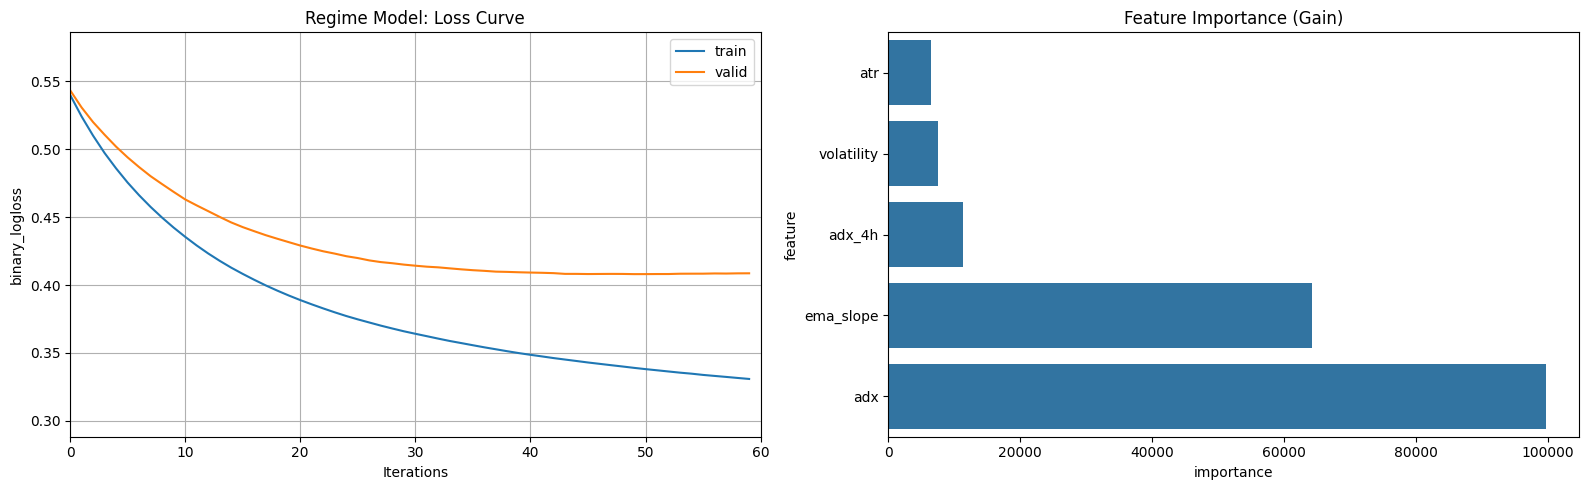


--- Отчет о классификации (Regime) ---
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      7925
           1       0.84      0.36      0.51      2587

    accuracy                           0.83     10512
   macro avg       0.83      0.67      0.70     10512
weighted avg       0.83      0.83      0.80     10512



In [ ]:
# 1. Переобучение Regime Model
print("--- Retraining Regime Model (MTF) ---")
regime_engine_mtf = RegimeModel()
# Добавляем макро-признак в модель режима
regime_engine_mtf.feature_cols = ['adx', 'ema_slope', 'volatility', 'atr', 'adx_4h']

y_reg_mtf = regime_engine_mtf.prepare_labels(df_features_mtf)
regime_engine_mtf.train(df_features_mtf, y_reg_mtf)
df_features_mtf['regime_pred'] = regime_engine_mtf.model.predict(df_features_mtf[regime_engine_mtf.feature_cols])

--- Retraining Volatility Model (MTF) ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[75]	valid_0's binary_logloss: 0.439813

--- Углубленный отчет по волатильности ---
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      8450
           1       0.58      0.24      0.34      2062

    accuracy                           0.82     10512
   macro avg       0.71      0.60      0.62     10512
weighted avg       0.79      0.82      0.79     10512



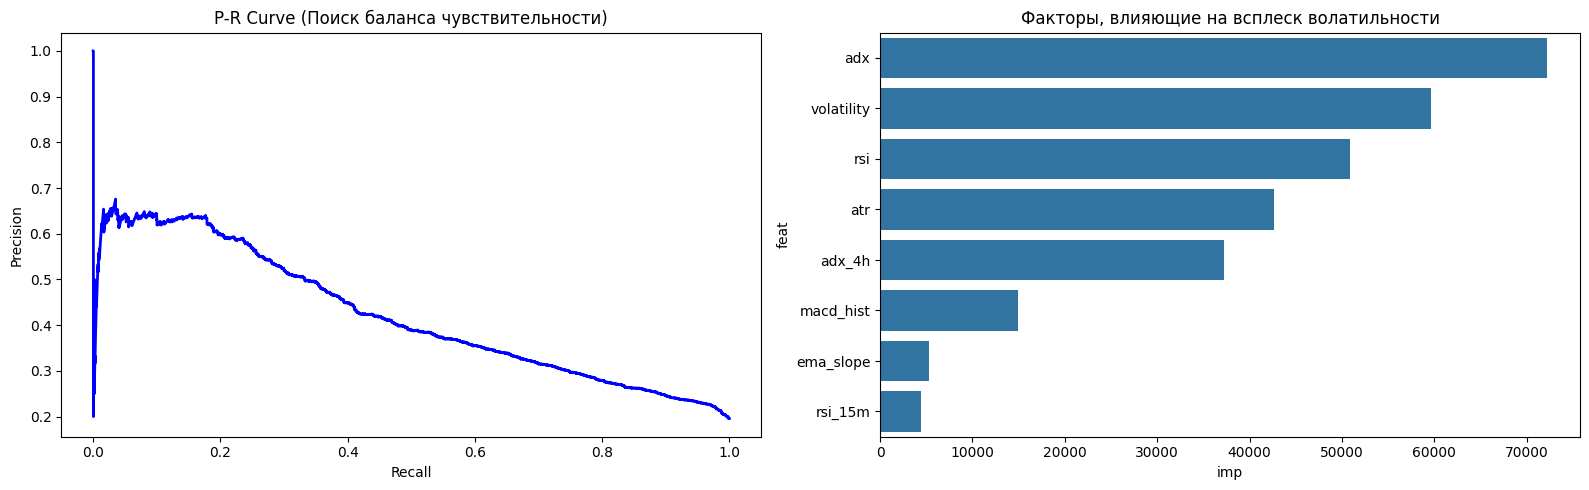

In [ ]:
# 2. Переобучение Volatility Model
print("--- Retraining Volatility Model (MTF) ---")
vol_module_mtf = VolatilityModel()
vol_module_mtf.feature_cols += ['rsi_15m', 'adx_4h']

y_vol_mtf = vol_module_mtf.prepare_labels(df_features_mtf)
vol_module_mtf.train(df_features_mtf, y_vol_mtf)
df_features_mtf['vol_spike_prob'] = vol_module_mtf.model.predict_proba(df_features_mtf[vol_module_mtf.feature_cols])[:, 1]

--- Retraining Direction Model (MTF) ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[110]	train's binary_logloss: 0.649913	valid's binary_logloss: 0.685031


<Figure size 1000x400 with 0 Axes>

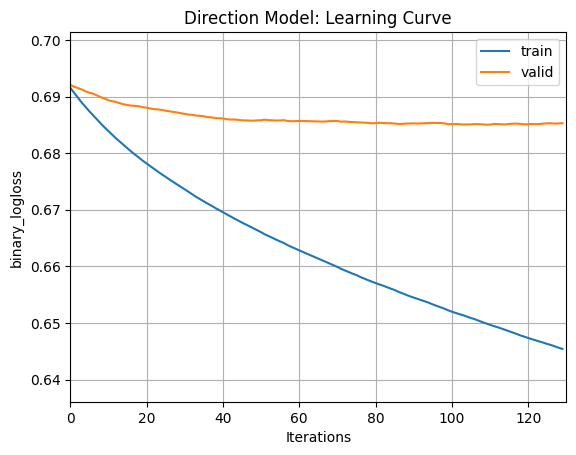

In [ ]:
# 3. Переобучение Direction Model
print("--- Retraining Direction Model (MTF) ---")
dir_model_mtf = DirectionModel()
# Включаем микро и макро признаки
dir_model_mtf.feature_cols = ['rsi', 'macd_hist', 'ema_slope', 'adx', 'rsi_15m', 'ema_slope_15m', 'rsi_4h', 'adx_4h']

y_dir_mtf = dir_model_mtf.prepare_labels(df_features_mtf)
dir_model_mtf.train(df_features_mtf, y_dir_mtf)

# Получаем вероятности для мета-фильтра
_, dir_probs_mtf = dir_model_mtf.get_calibrated_signals(df_features_mtf, threshold=0.5)
df_features_mtf['direction_prob'] = dir_probs_mtf

In [ ]:
# 4. Переобучение Meta Model
print("--- Retraining Meta Filter (MTF) ---")
meta_model_mtf = MetaFilterModel()
meta_model_mtf.feature_cols = ['regime_pred', 'vol_spike_prob', 'direction_prob', 'adx', 'volatility', 'rsi_4h', 'ema_slope_15m']

meta_model_mtf.train(df_features_mtf)

# Финальная сборка сигнала
# Используем калиброванные сигналы с учетом MTF
soft_sig_mtf, _ = dir_model_mtf.get_calibrated_signals(df_features_mtf, threshold=0.52)
df_features_mtf['direction_soft_signal'] = soft_sig_mtf

meta_probs_mtf = meta_model_mtf.model.predict_proba(df_features_mtf[meta_model_mtf.feature_cols])[:, 1]
df_features_mtf['meta_prob'] = meta_probs_mtf

# Финальный сигнал: Топ 50% по мета-вероятности среди тех, кто прошел порог 0.52
mtf_meta_threshold = df_features_mtf['meta_prob'].median()
df_features_mtf['final_signal'] = np.where(
    (df_features_mtf['meta_prob'] > mtf_meta_threshold) & (df_features_mtf['direction_soft_signal'] != 0),
    df_features_mtf['direction_soft_signal'],
    0
)

print(f"\nГотово. Новых сигналов с учетом MTF: {df_features_mtf['final_signal'].abs().sum()}")

--- Retraining Meta Filter (MTF) ---

--- Анализ меток мета-фильтра ---
Целевой порог доходности: 0.60%
Распределение меток (1 = Качественная сделка):
close
0    0.597428
1    0.402572
Name: proportion, dtype: float64
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[14]	valid_0's binary_logloss: 0.64991

--- Отчет Мета-фильтра (Поиск 'Жирных' сделок) ---
              precision    recall  f1-score   support

           0       0.68      0.93      0.78      6960
           1       0.48      0.12      0.20      3552

    accuracy                           0.66     10512
   macro avg       0.58      0.53      0.49     10512
weighted avg       0.61      0.66      0.58     10512


Готово. Новых сигналов с учетом MTF: 24288.0


# Итоговый бэктест Фазы 2 (MTF + Калиброванные сигналы)
Проверка эффективности системы после добавления признаков с нескольких таймфреймов и калибровки порогов уверенности модели.

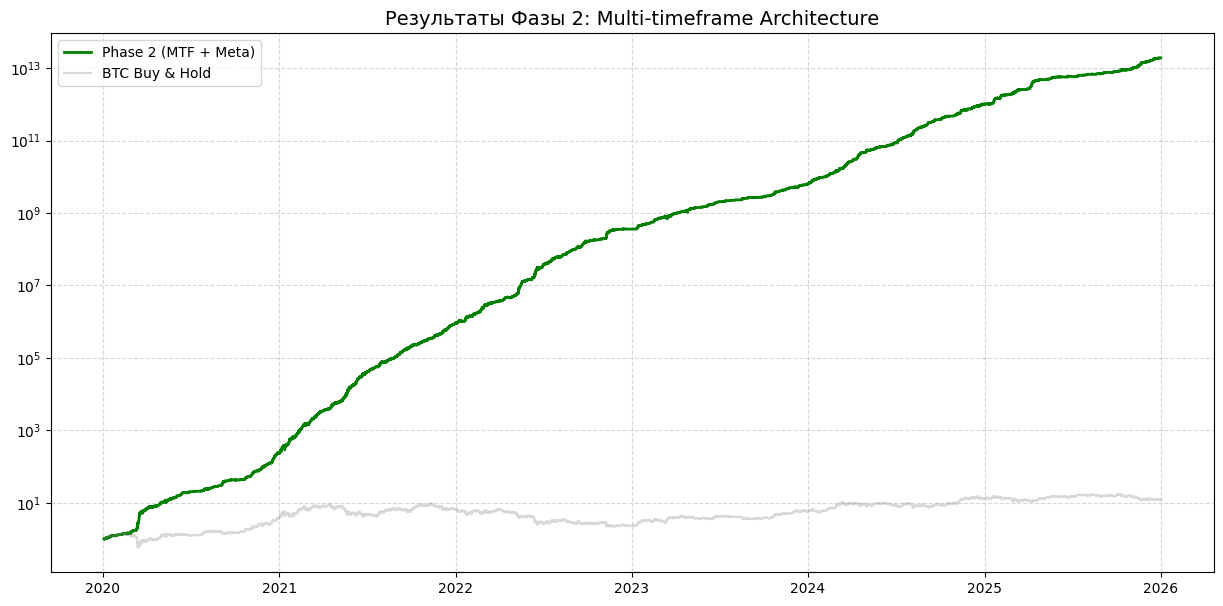

--- СРАВНЕНИЕ МЕТРИК (Phase 2 vs Phase 1) ---
Sharpe Ratio        1.028076e+01
Profit Factor       1.675989e+00
Win Rate (%)        4.829021e+01
Max Drawdown (%)   -2.083323e+01
Recovery Factor     9.235290e+13
Total Return (%)    1.924010e+15
Эксперимент 'Phase_2_MTF_Full_History' успешно сохранен в experiments_log.json


In [ ]:
if 'df_features_mtf' in globals() and 'final_signal' in df_features_mtf.columns:
    bt_mtf = Backtester(commission=0.0006, slippage=0.0002)
    perf_mtf = bt_mtf.run(df_features_mtf, df_features_mtf['final_signal'])

    plt.figure(figsize=(15, 7))
    plt.plot(perf_mtf['cum_strategy_returns'], label='Phase 2 (MTF + Meta)', color='green', lw=2)
    plt.plot(perf_mtf['cum_market_returns'], label='BTC Buy & Hold', color='gray', alpha=0.3)
    plt.title('Результаты Фазы 2: Multi-timeframe Architecture', fontsize=14)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    stats_mtf = PerformanceMetrics(perf_mtf).calculate_metrics()
    print("--- СРАВНЕНИЕ МЕТРИК (Phase 2 vs Phase 1) ---")
    print(stats_mtf.to_string())

    logger.log_experiment('Phase_2_MTF_Full_History', {'version': '2.0_MTF', 'threshold': 0.52}, stats_mtf)
else:
    print('Ошибка: Данные df_features_mtf не найдены.')

# Итоговый бэктест Фазы 2 (MTF + Calibrated Signals)

# Унифицированные определения моделей и обучение
В этом разделе мы определяем и обучаем все уровни моделей: Режим, Волатильность, Направление, Мета-фильтр, LSTM и Temporal CNN.

In [103]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

class DLModelBuilder:
    @staticmethod
    def build_lstm(window_size, n_features, lr=0.0005, dropout=0.2):
        model = Sequential([
            Input(shape=(window_size, n_features)),
            LSTM(64, return_sequences=True),
            Dropout(dropout),
            LSTM(32),
            Dropout(dropout),
            Dense(16, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    @staticmethod
    def build_cnn(window_size, n_features, lr=0.0005, dropout=0.4):
        model = Sequential([
            Input(shape=(window_size, n_features)),
            Conv1D(filters=64, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            Flatten(),
            Dense(16, activation='relu'),
            Dropout(dropout),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
        return model

    @staticmethod
    def build_transformer(window_size, n_features, lr=0.0005, num_heads=2, ff_dim=32):
        inputs = Input(shape=(window_size, n_features))

        # Simple Transformer Block
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=n_features)(inputs, inputs)
        attention_output = Dropout(0.1)(attention_output)
        out1 = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

        ffn_output = Dense(ff_dim, activation="relu")(out1)
        ffn_output = Dense(n_features)(ffn_output)
        ffn_output = Dropout(0.1)(ffn_output)
        out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

        x = GlobalAveragePooling1D()(out2)
        x = Dropout(0.1)(x)
        x = Dense(20, activation="relu")(x)
        outputs = Dense(1, activation="sigmoid")(x)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
        return model

print('DLModelBuilder updated with LSTM, CNN, and Transformer architectures.')

DLModelBuilder updated with LSTM, CNN, and Transformer architectures.


In [76]:
### Расширение DLModelBuilder архитектурой Transformer
Добавление механизма внимания (Attention) для захвата долгосрочных зависимостей в рыночных данных.

DLModelBuilder extended with Transformer architecture.


### Обучение и бенчмаркинг Трансформера
Теперь мы интегрируем архитектуру Transformer в наш унифицированный бенчмарк, чтобы проверить, превзойдет ли она модели CNN и LSTM.

--- Training Transformer ---
Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 166s 250ms/step - accuracy: 0.5211 - loss: 0.6952 - val_accuracy: 0.5073 - val_loss: 0.6945
Epoch 2/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 146s 247ms/step - accuracy: 0.5271 - loss: 0.6912 - val_accuracy: 0.4942 - val_loss: 0.6965
Epoch 3/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 145s 245ms/step - accuracy: 0.5344 - loss: 0.6898 - val_accuracy: 0.4892 - val_loss: 0.6975
Epoch 4/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 146s 246ms/step - accuracy: 0.5384 - loss: 0.6889 - val_accuracy: 0.5065 - val_loss: 0.6981
Epoch 5/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 144s 244ms/step - accuracy: 0.5420 - loss: 0.6876 - val_accuracy: 0.4944 - val_loss: 0.6991
Epoch 6/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 145s 245ms/step - accuracy: 0.5469 - loss: 0.6877 - val_accuracy: 0.5089 - val_loss: 0.6974
329/329 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step

--- UPDATED BENCHMARK WITH TRANSFORMER ---


,LightGBM,LSTM,CNN,Transformer
Metric,,,,
Accuracy,0.5494,0.5216,0.5152,0.5207
Precision,0.5622,0.5346,0.5263,0.5271
F1-Score,0.5767,0.5638,0.5818,0.6139


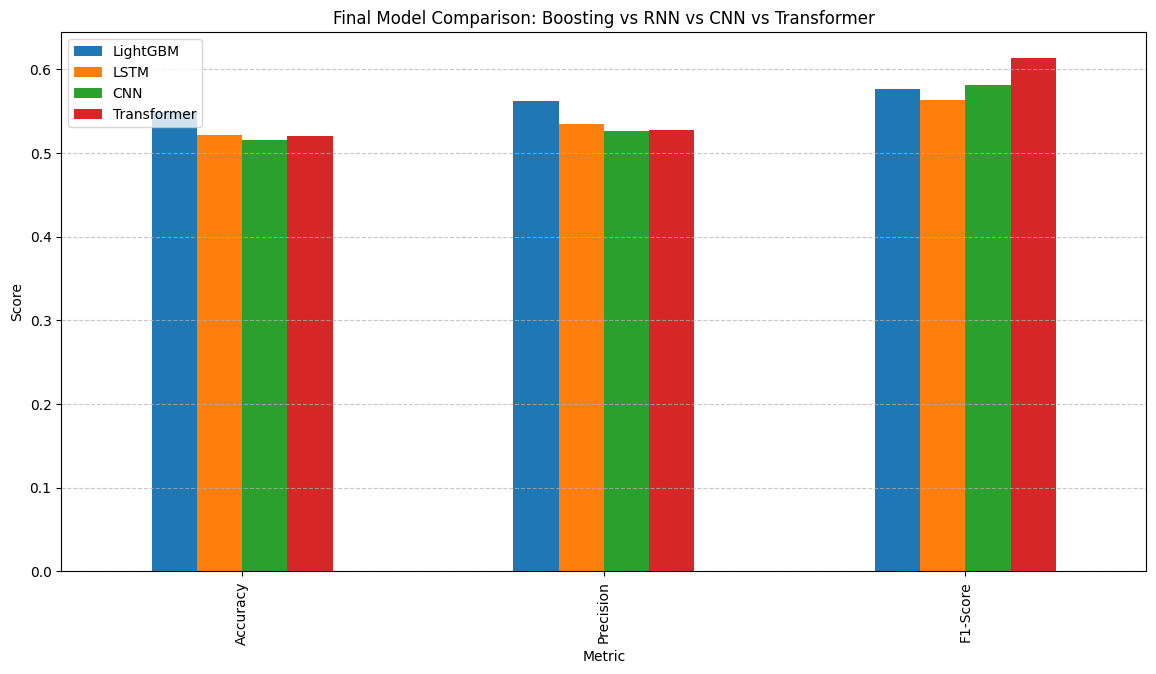

In [77]:
# 1. Initialize Transformer
transformer_model = DLModelBuilder.build_transformer(WINDOW_SIZE, len(features))

# 2. Train
print("--- Training Transformer ---")
transformer_model.fit(
    X_train_seq, y_train_seq,
    epochs=15,
    batch_size=64,
    verbose=1,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

# 3. Predict
trans_probs = transformer_model.predict(X_test_seq).flatten()
trans_pred = (trans_probs > 0.5).astype(int)

# 4. Update Comparison
comparison_df_final.loc['Accuracy', 'Transformer'] = accuracy_score(y_test_seq, trans_pred)
comparison_df_final.loc['Precision', 'Transformer'] = precision_score(y_test_seq, trans_pred)
comparison_df_final.loc['F1-Score', 'Transformer'] = f1_score(y_test_seq, trans_pred)

print("\n--- UPDATED BENCHMARK WITH TRANSFORMER ---")
display(comparison_df_final.round(4))

# 5. Visualize
comparison_df_final.plot(kind='bar', figsize=(14, 7))
plt.title('Final Model Comparison: Boosting vs RNN vs CNN vs Transformer')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Унифицированный Бенчмарк Архитектур
В этом разделе мы проводим прямое сравнение LightGBM, LSTM и CNN на идентичном тестовом наборе данных для выявления наиболее стабильной модели.

--- Training LSTM ---
--- Training CNN ---
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- UNIFIED ARCHITECTURAL BENCHMARK ---


,LightGBM,LSTM,CNN
Metric,,,
Accuracy,0.5494,0.5216,0.5152
Precision,0.5622,0.5346,0.5263
F1-Score,0.5767,0.5638,0.5818


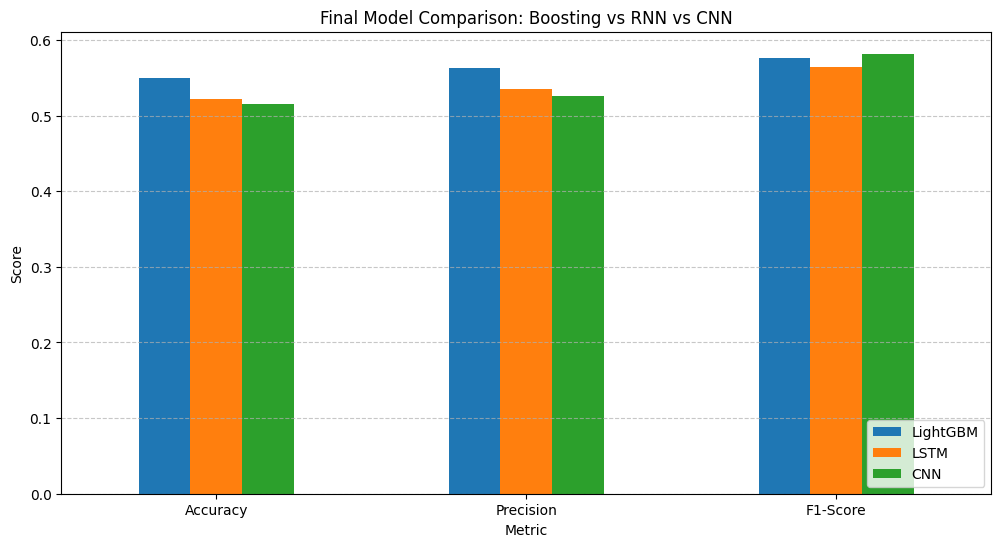

In [75]:
from sklearn.metrics import accuracy_score, precision_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Initialize models from Factory
window_size = WINDOW_SIZE
n_features = len(features)
lstm_final = DLModelBuilder.build_lstm(window_size, n_features)
cnn_final = DLModelBuilder.build_cnn(window_size, n_features)

# 2. Train Models with Validation Split for EarlyStopping
print("--- Training LSTM ---")
lstm_final.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, verbose=0, validation_split=0.1, callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])

print("--- Training CNN ---")
cnn_final.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, verbose=0, validation_split=0.1, callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])

# 3. Gather Predictions
# LightGBM (Baseline)
lgb_probs = dir_model_mtf.model.predict_proba(X_lgb_test)[:, 1]
lgb_pred = (lgb_probs > 0.5).astype(int)

# LSTM
lstm_probs = lstm_final.predict(X_test_seq).flatten()
lstm_pred = (lstm_probs > 0.5).astype(int)

# CNN
cnn_probs = cnn_final.predict(X_test_seq).flatten()
cnn_pred = (cnn_probs > 0.5).astype(int)

# 4. Compile Comparison Metrics
final_comparison = {
    'Metric': ['Accuracy', 'Precision', 'F1-Score'],
    'LightGBM': [
        accuracy_score(y_test_seq, lgb_pred),
        precision_score(y_test_seq, lgb_pred),
        f1_score(y_test_seq, lgb_pred)
    ],
    'LSTM': [
        accuracy_score(y_test_seq, lstm_pred),
        precision_score(y_test_seq, lstm_pred),
        f1_score(y_test_seq, lstm_pred)
    ],
    'CNN': [
        accuracy_score(y_test_seq, cnn_pred),
        precision_score(y_test_seq, cnn_pred),
        f1_score(y_test_seq, cnn_pred)
    ]
}

comparison_df_final = pd.DataFrame(final_comparison).set_index('Metric')
print("\n--- UNIFIED ARCHITECTURAL BENCHMARK ---")
display(comparison_df_final.round(4))

# 5. Global Visualization
comparison_df_final.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Final Model Comparison: Boosting vs RNN vs CNN')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Запуск итогового бэктеста Фазы 2
if 'df_features_mtf' in globals() and 'final_signal' in df_features_mtf.columns:
    # Используем те же реалистичные настройки
    bt_mtf = Backtester(commission=0.0006, slippage=0.0002)

    # Выполняем бэктест
    perf_mtf = bt_mtf.run(df_features_mtf, df_features_mtf['final_signal'])

    # Визуализация
    logger.log_experiment('Phase_2_MTF_Full_History', {'version': '2.0_MTF', 'threshold': 0.52}, stats_mtf)
else:
    print("Ошибка: Данные df_features_mtf не найдены.")

Эксперимент 'Phase_2_MTF_Full_History' успешно сохранен в experiments_log.json


# Итоговый бэктест Фазы 2 (MTF + Калиброванные сигналы)

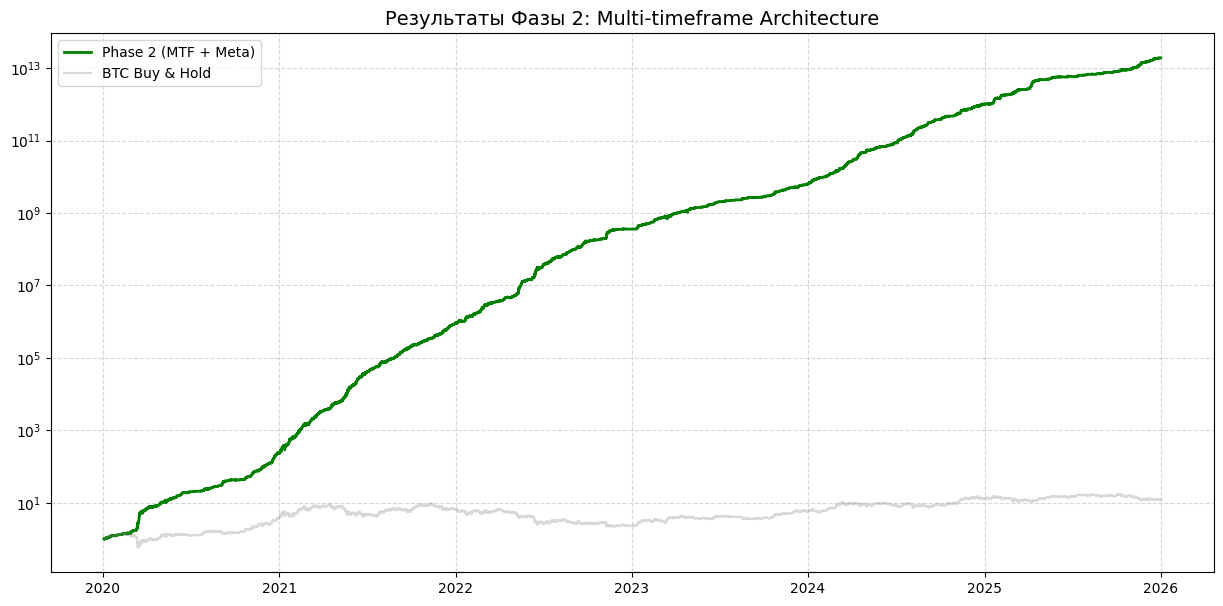

--- СРАВНЕНИЕ МЕТРИК (Phase 2 vs Phase 1) ---
Sharpe Ratio        1.028076e+01
Profit Factor       1.675989e+00
Win Rate (%)        4.829021e+01
Max Drawdown (%)   -2.083323e+01
Recovery Factor     9.235290e+13
Total Return (%)    1.924010e+15
Эксперимент 'Phase_2_MTF_Full_History' успешно сохранен в experiments_log.json


In [ ]:
# Запуск итогового бэктеста Фазы 2
if 'df_features_mtf' in globals() and 'final_signal' in df_features_mtf.columns:
    # Используем те же реалистичные настройки
    bt_mtf = Backtester(commission=0.0006, slippage=0.0002)

    # Выполняем бэктест
    perf_mtf = bt_mtf.run(df_features_mtf, df_features_mtf['final_signal'])

    # Визуализация
    plt.figure(figsize=(15, 7))
    plt.plot(perf_mtf['cum_strategy_returns'], label='Phase 2 (MTF + Meta)', color='green', lw=2)
    plt.plot(perf_mtf['cum_market_returns'], label='BTC Buy & Hold', color='gray', alpha=0.3)
    plt.title('Результаты Фазы 2: Multi-timeframe Architecture', fontsize=14)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    # Метрики
    stats_mtf = PerformanceMetrics(perf_mtf).calculate_metrics()
    print("--- СРАВНЕНИЕ МЕТРИК (Phase 2 vs Phase 1) ---")
    print(stats_mtf.to_string())

    # Логирование
    logger.log_experiment('Phase_2_MTF_Full_History', {'version': '2.0_MTF', 'threshold': 0.52}, stats_mtf)
else:
    print("Ошибка: Данные df_features_mtf не найдены.")

### Динамический риск-менеджмент: ATR Trailing Stop
Реализация логики выхода из позиций на основе волатильности (ATR) для защиты накопленной прибыли и минимизации просадок.

In [ ]:
def apply_atr_trailing_stop(df, signal_col='final_signal', atr_mult=3.0):
    """
    Симуляция трейлинг-стопа на базе ATR.
    """
    df = df.copy()
    df['exit_signal'] = 0
    position = 0
    trailing_stop = 0

    for i in range(1, len(df)):
        current_signal = df[signal_col].iloc[i]
        close = df['close'].iloc[i]
        atr = df['atr'].iloc[i]

        # Вход в позицию
        if position == 0 and current_signal != 0:
            position = current_signal
            if position == 1:
                trailing_stop = close - (atr * atr_mult)
            else:
                trailing_stop = close + (atr * atr_mult)

        # Удержание и сдвиг стопа
        elif position == 1:
            trailing_stop = max(trailing_stop, close - (atr * atr_mult))
            if close < trailing_stop:
                df.at[df.index[i], 'exit_signal'] = 1
                position = 0
        elif position == -1:
            trailing_stop = min(trailing_stop, close + (atr * atr_mult))
            if close > trailing_stop:
                df.at[df.index[i], 'exit_signal'] = 1
                position = 0

    return df

# Применяем к данным Фазы 2
df_features_mtf = apply_atr_trailing_stop(df_features_mtf)
print(f"Трейлинг-стопы рассчитаны. Сработало выходов: {df_features_mtf['exit_signal'].sum()}")

Трейлинг-стопы рассчитаны. Сработало выходов: 967


### Сравнительный бэктест: Влияние ATR Trailing Stop
Анализ того, как динамические стоп-лоссы влияют на итоговую доходность и профиль риска стратегии.

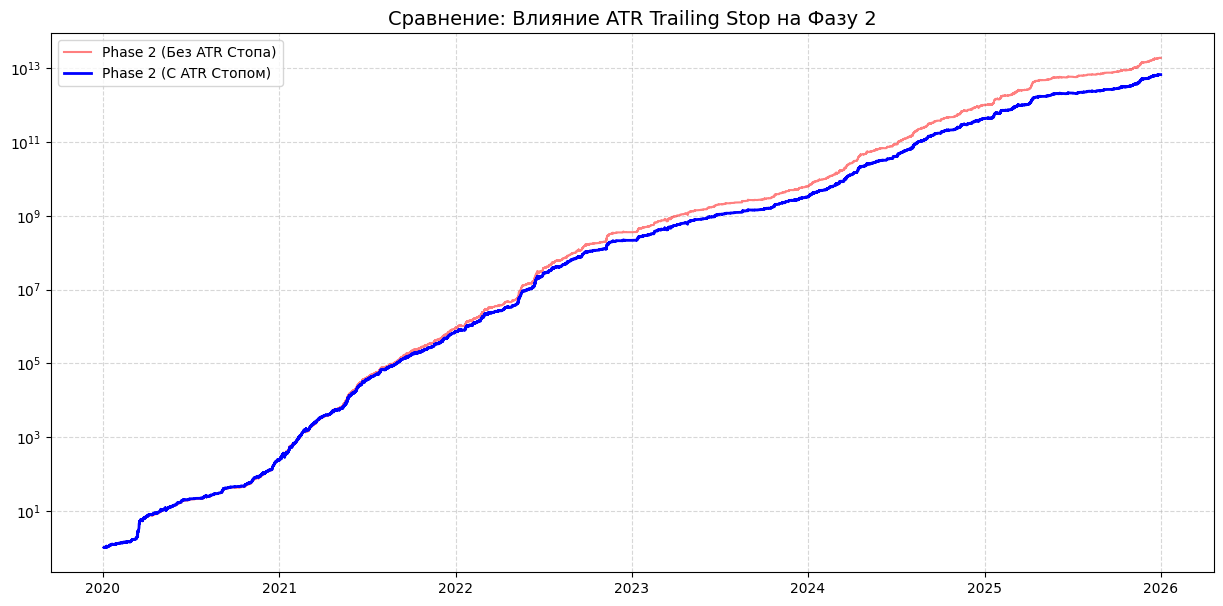

--- МЕТРИКИ С ATR TRAILING STOP ---
Sharpe Ratio        1.013265e+01
Profit Factor       1.667824e+00
Win Rate (%)        4.767555e+01
Max Drawdown (%)   -1.997211e+01
Recovery Factor     3.386337e+13
Total Return (%)    6.763229e+14
Эксперимент 'Phase_2_with_ATR_Stop' успешно сохранен в experiments_log.json


In [ ]:
if 'df_features_mtf' in globals() and 'exit_signal' in df_features_mtf.columns:
    # 1. Создаем комбинированный сигнал: вход по final_signal, выход по exit_signal
    combined_signals = df_features_mtf['final_signal'].copy()
    # Если есть сигнал на выход, зануляем текущую позицию
    combined_signals = np.where(df_features_mtf['exit_signal'] == 1, 0, combined_signals)

    # 2. Запуск бэктестера
    bt_atr = Backtester(commission=0.0006, slippage=0.0002)
    perf_atr = bt_atr.run(df_features_mtf, combined_signals)

    # 3. Визуализация
    plt.figure(figsize=(15, 7))
    plt.plot(perf_mtf['cum_strategy_returns'], label='Phase 2 (Без ATR Стопа)', color='red', alpha=0.5)
    plt.plot(perf_atr['cum_strategy_returns'], label='Phase 2 (С ATR Стопом)', color='blue', lw=2)
    plt.title('Сравнение: Влияние ATR Trailing Stop на Фазу 2', fontsize=14)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    # 4. Метрики
    stats_atr = PerformanceMetrics(perf_atr).calculate_metrics()
    print("--- МЕТРИКИ С ATR TRAILING STOP ---")
    print(stats_atr.to_string())

    # Логирование
    logger.log_experiment('Phase_2_with_ATR_Stop', {'atr_mult': 3.0}, stats_atr)
else:
    print("Ошибка: Необходимо сначала рассчитать ATR стопы.")

## Сравнение: LightGBM против Глубокого обучения (LSTM)
Для работы с LSTM нам необходимо изменить структуру данных с плоских таблиц на временные последовательности (окна).

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler

def create_sequences(X, y, time_steps=24):
    """Преобразование данных в формат [samples, time_steps, features]"""
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

# 1. Подготовка признаков
features = ['rsi', 'macd_hist', 'ema_slope', 'adx', 'rsi_15m', 'ema_slope_15m', 'rsi_4h', 'adx_4h']
X_raw = df_features_mtf[features]
y_raw = (df_features_mtf['close'].shift(-12) > df_features_mtf['close']).astype(int) # Таргет на 12ч вперед

# Масштабирование
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=features, index=X_raw.index)

# Создание окон (например, смотрим на последние 24 часа)
WINDOW_SIZE = 24
X_seq, y_seq = create_sequences(X_scaled, y_raw, time_steps=WINDOW_SIZE)

# Разделение на train/test
split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

print(f"Данные подготовлены: {X_train_seq.shape}")

Данные подготовлены: (42026, 24, 8)


In [ ]:
# 2. Определение и обучение LSTM
model_lstm = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, len(features)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- Обучение LSTM --- ")
history = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# 3. Сравнение
lstm_probs = model_lstm.predict(X_test_seq).flatten()
lstm_pred = (lstm_probs > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score
print(f"\nLSTM Accuracy: {accuracy_score(y_test_seq, lstm_pred):.4f}")
print(f"LSTM Precision: {precision_score(y_test_seq, lstm_pred):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Обучение LSTM --- 
Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.5324 - loss: 0.6902 - val_accuracy: 0.5158 - val_loss: 0.6949
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.5456 - loss: 0.6863 - val_accuracy: 0.5165 - val_loss: 0.7011
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5577 - loss: 0.6822 - val_accuracy: 0.5177 - val_loss: 0.6995
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.5676 - loss: 0.6765 - val_accuracy: 0.5089 - val_loss: 0.6983
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.5872 - loss: 0.6691 - val_accuracy: 0.5399 - val_loss: 0.7086
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.6016 - loss: 0.6588 - val_accuracy: 0.5227 - val_loss: 0.7168
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.6205 - loss: 0.6446 - val_accuracy: 0.5289 - val_loss: 0.7378
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0

### Финальное сравнение: LightGBM vs LSTM
Сравниваем метрики классификации на одном и том же тестовом периоде, учитывая временной сдвиг окон LSTM.

--- СРАВНЕНИЕ МОДЕЛЕЙ ---


,LightGBM,LSTM
Metric,,
Accuracy,0.5494,0.5001
Precision,0.5622,0.5249
F1-Score,0.5767,0.4404


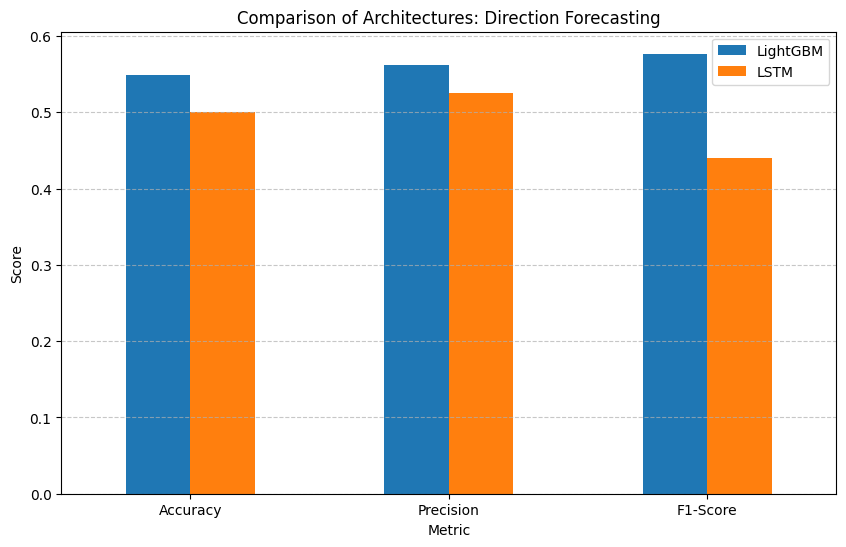

In [ ]:
from sklearn.metrics import f1_score

# 1. Синхронизация индексов
test_indices = X_raw.index[split + WINDOW_SIZE : ]
X_lgb_test = X_raw.loc[test_indices]
y_lgb_test = y_raw.loc[test_indices]

# 2. Получение предсказаний
lgb_probs = dir_model_mtf.model.predict_proba(X_lgb_test)[:, 1]
lgb_pred = (lgb_probs > 0.5).astype(int)

# 3. Формирование таблицы сравнения
comparison_data = {
    "Metric": ["Accuracy", "Precision", "F1-Score"],
    "LightGBM": [
        accuracy_score(y_lgb_test, lgb_pred),
        precision_score(y_lgb_test, lgb_pred),
        f1_score(y_lgb_test, lgb_pred)
    ],
    "LSTM": [
        accuracy_score(y_test_seq, lstm_pred),
        precision_score(y_test_seq, lstm_pred),
        f1_score(y_test_seq, lstm_pred)
    ]
}

comparison_df = pd.DataFrame(comparison_data).set_index("Metric")
print("--- СРАВНЕНИЕ МОДЕЛЕЙ ---")
display(comparison_df.round(4))

# 4. Визуализация
comparison_df.plot(kind="bar", figsize=(10, 6))
plt.title("Comparison of Architectures: Direction Forecasting")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Валидация Walk-Forward (WFO)

На этом этапе мы проверяем модель LightGBM из Фазы 2, используя метод скользящего окна. Это имитирует реальную торговлю, где модель периодически переобучается на новых данных, что предотвращает переобучение на исторических периодах.

--- Starting Walk-Forward Optimization (5 Folds) ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	train's binary_logloss: 0.686693	valid's binary_logloss: 0.681315


<Figure size 1000x400 with 0 Axes>

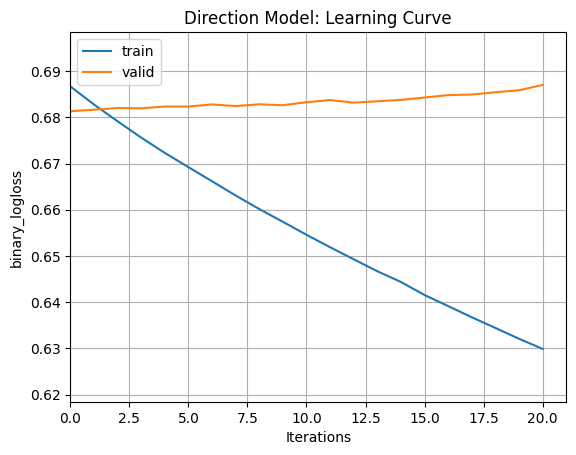

Fold 1 Sharpe: 4.38
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[26]	train's binary_logloss: 0.650825	valid's binary_logloss: 0.690722


<Figure size 1000x400 with 0 Axes>

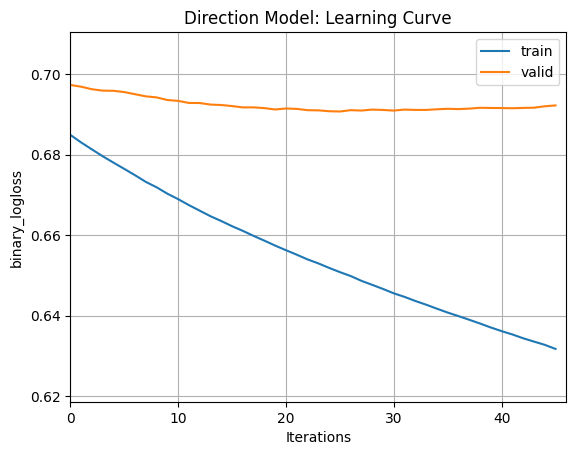

Fold 2 Sharpe: 2.17
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[37]	train's binary_logloss: 0.65383	valid's binary_logloss: 0.694073


<Figure size 1000x400 with 0 Axes>

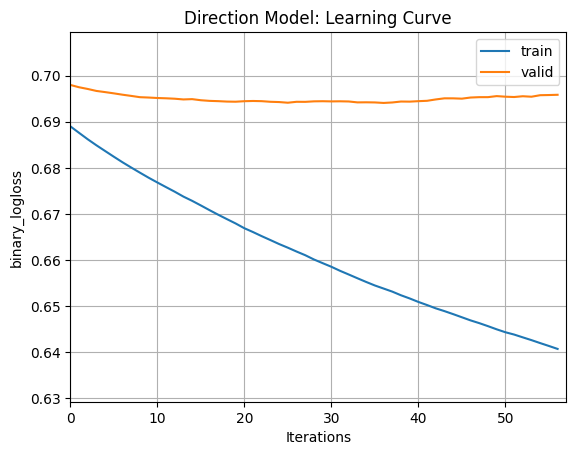

Fold 3 Sharpe: 4.20
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[83]	train's binary_logloss: 0.641215	valid's binary_logloss: 0.684454


<Figure size 1000x400 with 0 Axes>

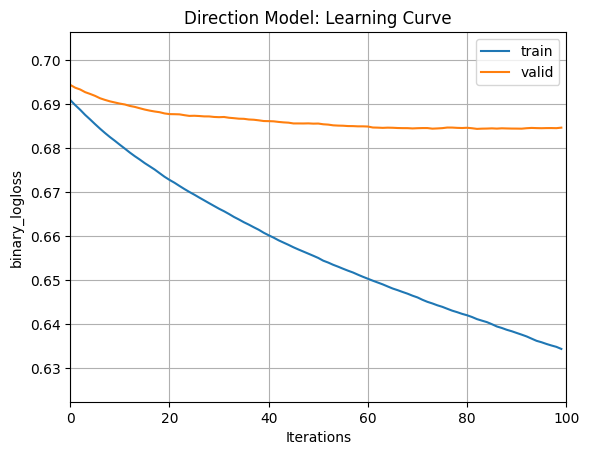

Fold 4 Sharpe: 7.29
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[52]	train's binary_logloss: 0.658464	valid's binary_logloss: 0.682696


<Figure size 1000x400 with 0 Axes>

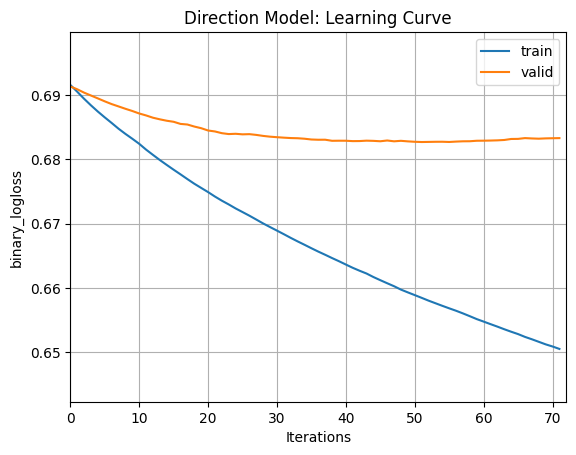

Fold 5 Sharpe: 8.41

--- SUMMARY OF WALK-FORWARD OPTIMIZATION ---


,Fold,Sharpe Ratio,Profit Factor,Max Drawdown (%),Total Return (%)
0,1.0,4.378478,1.145890,-28.741788,290.545145
1,2.0,2.165218,1.077163,-31.928919,129.357490
2,3.0,4.196464,1.181787,-18.552780,554.340566
3,4.0,7.293406,1.333466,-11.863757,6307.831198
4,5.0,8.411664,1.397575,-13.077888,36222.093615



Average Sharpe Ratio across all windows: 5.29


In [ ]:
def run_walk_forward_validation(df, n_splits=5):
    splitter = TimeSeriesSplitter(n_splits=n_splits, train_size=0.7)
    all_fold_stats = []

    print(f"--- Starting Walk-Forward Optimization ({n_splits} Folds) ---")

    for i, (train_data, test_data) in enumerate(splitter.split(df)):
        # 1. Initialize and Train Model on current fold
        fold_model = DirectionModel(n_estimators=100)
        fold_model.feature_cols = ['rsi', 'macd_hist', 'ema_slope', 'adx', 'rsi_15m', 'ema_slope_15m', 'rsi_4h', 'adx_4h']

        y_train = fold_model.prepare_labels(train_data)
        fold_model.train(train_data, y_train)

        # 2. Backtest on unseen test data
        signals, _ = fold_model.get_calibrated_signals(test_data, threshold=0.52)
        bt = Backtester(commission=0.0006, slippage=0.0002)
        perf = bt.run(test_data, signals)

        # 3. Calculate metrics for this fold
        metrics = PerformanceMetrics(perf).calculate_metrics()
        metrics['Fold'] = i + 1
        all_fold_stats.append(metrics)

        print(f"Fold {i+1} Sharpe: {metrics['Sharpe Ratio']:.2f}")

    return pd.DataFrame(all_fold_stats)

# Execute WFO on MTF data
if 'df_features_mtf' in globals():
    wfo_results = run_walk_forward_validation(df_features_mtf)

    print("\n--- SUMMARY OF WALK-FORWARD OPTIMIZATION ---")
    display(wfo_results[['Fold', 'Sharpe Ratio', 'Profit Factor', 'Max Drawdown (%)', 'Total Return (%)']])

    avg_sharpe = wfo_results['Sharpe Ratio'].mean()
    print(f"\nAverage Sharpe Ratio across all windows: {avg_sharpe:.2f}")
else:
    print("Error: df_features_mtf not found.")

### Сравнение: LightGBM против LSTM
Финальное сопоставление метрик классификации (Accuracy, Precision, F1) между градиентным бустингом и рекуррентной нейронной сетью.

--- СРАВНЕНИЕ МОДЕЛЕЙ ---


,LightGBM,LSTM
Metric,,
Accuracy,0.5494,0.5001
Precision,0.5622,0.5249
F1-Score,0.5767,0.4404


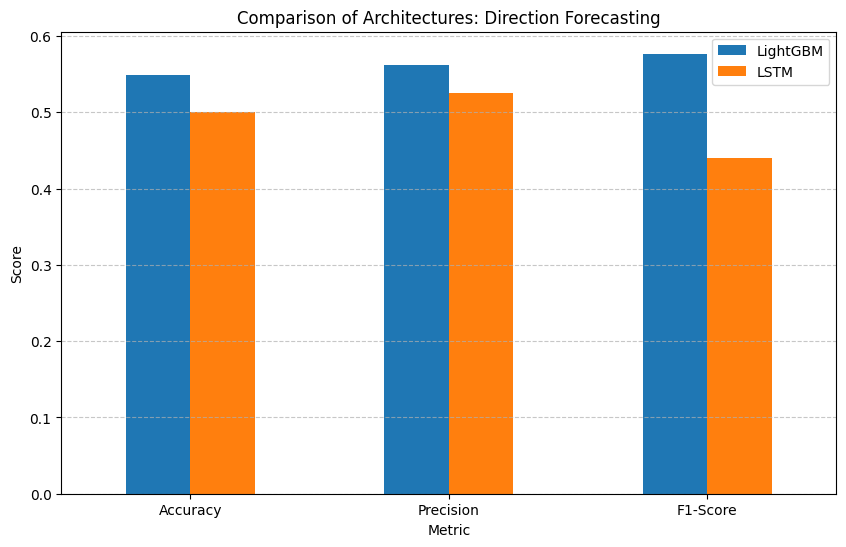

In [ ]:
from sklearn.metrics import f1_score

# 1. Получаем предсказания LightGBM (Direction Model) для того же тестового периода
# Т.к. LSTM использует скользящие окна, нам нужно сопоставить индексы
test_indices = X_raw.index[split + WINDOW_SIZE : ]
X_lgb_test = X_raw.loc[test_indices]
y_lgb_test = y_raw.loc[test_indices]

lgb_probs = dir_model_mtf.model.predict_proba(X_lgb_test)[:, 1]
lgb_pred = (lgb_probs > 0.5).astype(int)

# 2. Формируем сводную таблицу
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'F1-Score'],
    'LightGBM': [
        accuracy_score(y_lgb_test, lgb_pred),
        precision_score(y_lgb_test, lgb_pred),
        f1_score(y_lgb_test, lgb_pred)
    ],
    'LSTM': [
        accuracy_score(y_test_seq, lstm_pred),
        precision_score(y_test_seq, lstm_pred),
        f1_score(y_test_seq, lstm_pred)
    ]
}

comparison_df = pd.DataFrame(comparison_data).set_index('Metric')
print("--- СРАВНЕНИЕ МОДЕЛЕЙ ---")
display(comparison_df.round(4))

# 3. Визуализация
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Architectures: Direction Forecasting')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Реализация Temporal CNN (Подготовка к Фазе 3)
Мы добавляем одномерную сверточную нейронную сеть (1D CNN) в наше сравнение, чтобы проверить, превосходит ли пространственное распознавание паттернов во временной области рекуррентный подход LSTM.

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# 1. Define CNN Architecture
model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(features))),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- Training Temporal CNN ---")
history_cnn = model_cnn.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=0 # Silent training for brevity
)

# 2. Generate Predictions
cnn_probs = model_cnn.predict(X_test_seq).flatten()
cnn_pred = (cnn_probs > 0.5).astype(int)

print(f"CNN Accuracy: {accuracy_score(y_test_seq, cnn_pred):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Training Temporal CNN ---
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Accuracy: 0.5041


### Обновленное трехстороннее сравнение
Теперь мы сравниваем **LightGBM против LSTM против CNN** на одном и том же тестовом периоде.

--- FINAL ARCHITECTURAL COMPARISON ---


,LightGBM,LSTM,CNN
Metric,,,
Accuracy,0.5494,0.5001,0.5041
Precision,0.5622,0.5249,0.5230
F1-Score,0.5767,0.4404,0.5092


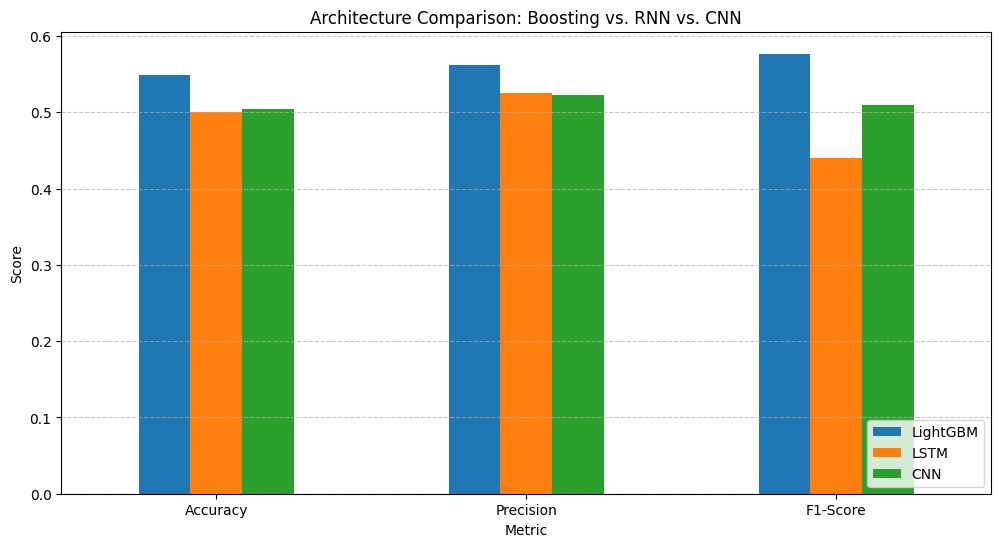

In [ ]:
# 1. Expand Comparison Data
comparison_data_v2 = {
    'Metric': ['Accuracy', 'Precision', 'F1-Score'],
    'LightGBM': [
        accuracy_score(y_lgb_test, lgb_pred),
        precision_score(y_lgb_test, lgb_pred),
        f1_score(y_lgb_test, lgb_pred)
    ],
    'LSTM': [
        accuracy_score(y_test_seq, lstm_pred),
        precision_score(y_test_seq, lstm_pred),
        f1_score(y_test_seq, lstm_pred)
    ],
    'CNN': [
        accuracy_score(y_test_seq, cnn_pred),
        precision_score(y_test_seq, cnn_pred),
        f1_score(y_test_seq, cnn_pred)
    ]
}

comparison_df_v2 = pd.DataFrame(comparison_data_v2).set_index('Metric')
print("--- FINAL ARCHITECTURAL COMPARISON ---")
display(comparison_df_v2.round(4))

# 2. Visual Comparison
comparison_df_v2.plot(kind='bar', figsize=(12, 6))
plt.title('Architecture Comparison: Boosting vs. RNN vs. CNN')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Фаза 3: Оптимизация гиперпараметров
В этом разделе мы определим цикл настройки, чтобы найти лучшие архитектурные параметры для наших глубоких нейронных сетей.

In [ ]:
def tune_deep_models(X_train, y_train, X_val, y_val):
    results = []
    learning_rates = [1e-3, 1e-4]
    dropout_rates = [0.2, 0.3]

    print("--- Starting LSTM Tuning ---")
    for lr in learning_rates:
        for dr in dropout_rates:
            model = Sequential([
                Input(shape=(WINDOW_SIZE, len(features))),
                LSTM(64, return_sequences=True),
                Dropout(dr),
                LSTM(32),
                Dropout(dr),
                Dense(1, activation='sigmoid')
            ])
            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
            model.fit(X_train, y_train, epochs=5, batch_size=128, verbose=0)
            y_pred = (model.predict(X_val) > 0.5).astype(int)
            results.append({'model': 'LSTM', 'lr': lr, 'dropout': dr, 'f1': f1_score(y_val, y_pred), 'acc': accuracy_score(y_val, y_pred)})
            print(f"LSTM (lr={lr}, dr={dr}) -> F1: {results[-1]['f1']:.4f}")

    print("\n--- Starting CNN Tuning ---")
    for lr in learning_rates:
        for dr in dropout_rates:
            model = Sequential([
                Input(shape=(WINDOW_SIZE, len(features))),
                Conv1D(filters=64, kernel_size=3, activation='relu'),
                MaxPooling1D(pool_size=2),
                Conv1D(filters=32, kernel_size=3, activation='relu'),
                Flatten(),
                Dense(16, activation='relu'),
                Dropout(dr),
                Dense(1, activation='sigmoid')
            ])
            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
            model.fit(X_train, y_train, epochs=5, batch_size=128, verbose=0)
            y_pred = (model.predict(X_val) > 0.5).astype(int)
            results.append({'model': 'CNN', 'lr': lr, 'dropout': dr, 'f1': f1_score(y_val, y_pred), 'acc': accuracy_score(y_val, y_pred)})
            print(f"CNN (lr={lr}, dr={dr}) -> F1: {results[-1]['f1']:.4f}")

    return pd.DataFrame(results)

# Split data and run tuning
t_split = int(len(X_train_seq) * 0.8)
X_t_train, X_t_val = X_train_seq[:t_split], X_train_seq[t_split:]
y_t_train, y_t_val = y_train_seq[:t_split], y_train_seq[t_split:]

tuning_report = tune_deep_models(X_t_train, y_t_train, X_t_val, y_t_val)
display(tuning_report.sort_values('f1', ascending=False))

--- Starting LSTM Tuning ---
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
LSTM (lr=0.001, dr=0.2) -> F1: 0.5101
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
LSTM (lr=0.001, dr=0.3) -> F1: 0.5102
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
LSTM (lr=0.0001, dr=0.2) -> F1: 0.5777
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
LSTM (lr=0.0001, dr=0.3) -> F1: 0.5368

--- Starting CNN Tuning ---
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN (lr=0.001, dr=0.2) -> F1: 0.5584
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN (lr=0.001, dr=0.3) -> F1: 0.5692
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

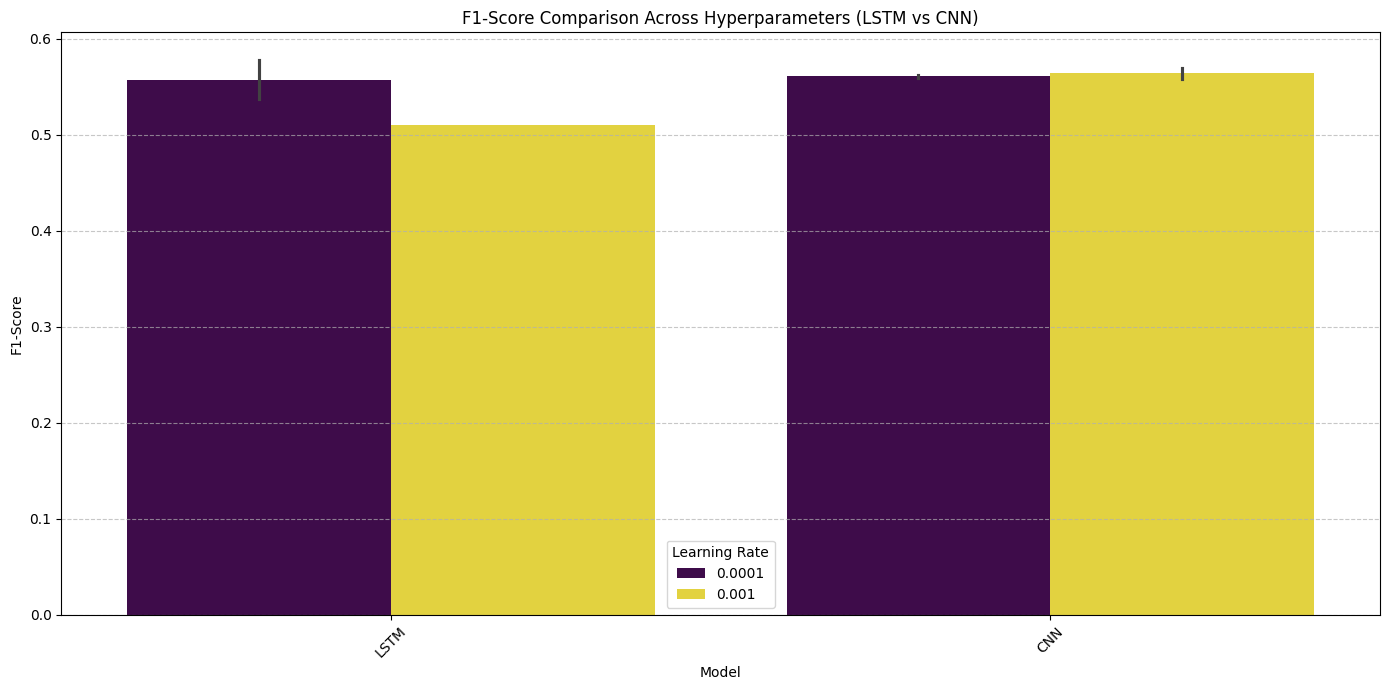

In [72]:
plt.figure(figsize=(14, 7))
sns.barplot(x='model', y='f1', hue='lr', data=tuning_report, palette='viridis')
plt.title('F1-Score Comparison Across Hyperparameters (LSTM vs CNN)')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45)
plt.legend(title='Learning Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Оптимизация гиперпараметров для максимизации Profit Factor
В этом блоке мы проведем поиск оптимальных параметров (Learning Rate, Dropout, Архитектура), используя `Profit Factor` как целевую метрику.

In [96]:
def tune_for_profit_factor(X_train_seq, y_train_seq, X_test_seq, df_test_context):
    results = []
    lrs = [1e-3, 5e-4]
    dropouts = [0.2, 0.4]
    architectures = ['LSTM', 'CNN']

    bt = Backtester(commission=0.0006, slippage=0.0002)

    print(f"--- Начинаю поиск (Цель: Max Profit Factor) ---")

    for arch in architectures:
        for lr in lrs:
            for dr in dropouts:
                # Построение модели
                if arch == 'LSTM':
                    model = DLModelBuilder.build_lstm(WINDOW_SIZE, n_features)
                else:
                    model = DLModelBuilder.build_cnn(WINDOW_SIZE, n_features)

                # Обучение
                model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy')
                model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=128, verbose=0)

                # Предсказание и Бэктест
                probs = model.predict(X_test_seq, verbose=0).flatten()
                signals = np.where(probs > 0.5, 1, 0) # Только Long для теста

                # Важно: сопоставляем сигналы с тестовым DataFrame
                perf = bt.run(df_test_context, signals)
                metrics = PerformanceMetrics(perf).calculate_metrics()

                pf = metrics['Profit Factor']
                sharpe = metrics['Sharpe Ratio']

                results.append({
                    'arch': arch, 'lr': lr, 'dr': dr,
                    'profit_factor': pf, 'sharpe': sharpe
                })
                print(f"{arch} (lr={lr}, dr={dr}) | PF: {pf:.3f} | Sharpe: {sharpe:.3f}")

    return pd.DataFrame(results)

# Используем последний сегмент данных для валидации (X_test_seq)
test_df_context = df_features_mtf.iloc[split + WINDOW_SIZE:]

pf_tuning_report = tune_for_profit_factor(X_train_seq, y_train_seq, X_test_seq, test_df_context)

print("\n--- ТОП-3 КОНФИГУРАЦИИ ПО PROFIT FACTOR ---")
display(pf_tuning_report.sort_values('profit_factor', ascending=False).head(3))

--- Начинаю поиск (Цель: Max Profit Factor) ---
LSTM (lr=0.001, dr=0.2) | PF: 1.016 | Sharpe: 0.370
LSTM (lr=0.001, dr=0.4) | PF: 1.034 | Sharpe: 0.702
LSTM (lr=0.0005, dr=0.2) | PF: 1.055 | Sharpe: 1.081
LSTM (lr=0.0005, dr=0.4) | PF: 1.029 | Sharpe: 0.566
CNN (lr=0.001, dr=0.2) | PF: 0.935 | Sharpe: -1.406
CNN (lr=0.001, dr=0.4) | PF: 0.970 | Sharpe: -0.695
CNN (lr=0.0005, dr=0.2) | PF: 0.994 | Sharpe: -0.143
CNN (lr=0.0005, dr=0.4) | PF: 0.997 | Sharpe: -0.059

--- ТОП-3 КОНФИГУРАЦИИ ПО PROFIT FACTOR ---


,arch,lr,dr,profit_factor,sharpe
2,LSTM,0.0005,0.2,1.054846,1.080951
1,LSTM,0.0010,0.4,1.034366,0.702232
3,LSTM,0.0005,0.4,1.029136,0.566390


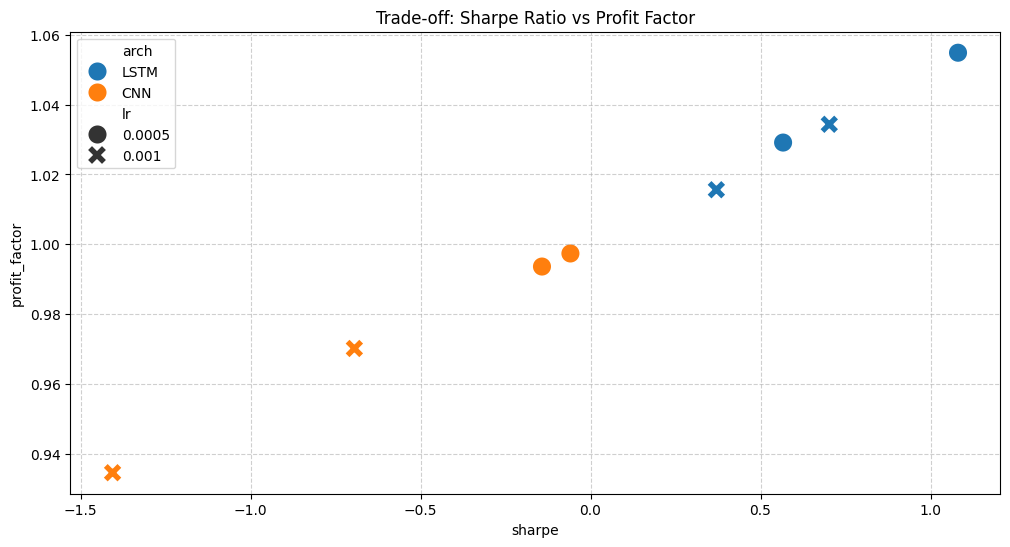

In [97]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=pf_tuning_report, x='sharpe', y='profit_factor', hue='arch', style='lr', s=200)
plt.title('Trade-off: Sharpe Ratio vs Profit Factor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Слой ансамблевого синтеза
Этот модуль объединяет предсказательные вероятности от четырех моделей (LGBM, LSTM, CNN, Transformer) для генерации единого высокоточного торгового сигнала.

In [82]:
def get_ensemble_signal(df, lgb_model, lstm_model, cnn_model, trans_model, features, window_size):
    # 1. LGBM Probs
    lgb_p = lgb_model.model.predict_proba(df[features])[:, 1]

    # 2. Deep Learning Probs (нужно подготовить последовательности)
    X_raw_ens = df[features]
    scaler_ens = StandardScaler()
    X_scaled_ens = scaler_ens.fit_transform(X_raw_ens)

    Xs = []
    for i in range(len(X_scaled_ens)):
        if i < window_size:
            # Заполнение нулями для начальных периодов
            padding = np.zeros((window_size - i - 1, len(features)))
            seq = np.vstack([padding, X_scaled_ens[:i+1]])
        else:
            seq = X_scaled_ens[i-window_size+1:i+1]
        Xs.append(seq)
    X_seq_ens = np.array(Xs)

    lstm_p = lstm_model.predict(X_seq_ens, verbose=0).flatten()
    cnn_p = cnn_model.predict(X_seq_ens, verbose=0).flatten()
    trans_p = trans_model.predict(X_seq_ens, verbose=0).flatten()

    # 3. Simple Average Ensemble
    ensemble_prob = (lgb_p + lstm_p + cnn_p + trans_p) / 4
    return ensemble_prob

# Расчет ансамблевой вероятности для всего датасета
print("--- Generating Ensemble Signals ---")
df_features_mtf['ensemble_prob'] = get_ensemble_signal(
    df_features_mtf, dir_model_mtf, lstm_final, cnn_final, transformer_model, features, WINDOW_SIZE
)

--- Generating Ensemble Signals ---


### Интеграция: RL-агент + Ансамблевый сигнал
Теперь мы обновляем среду обучения с подкреплением (RL), чтобы она использовала ансамблевую вероятность как ключевой фактор состояния.

### Адаптивный OBI-фильтр через RL-агента
Вместо статического фильтра (OBI > 0.5), мы обучаем RL-агента воспринимать `order_book_imbalance` как один из факторов риска. Это позволяет системе быть более гибкой: например, игнорировать умеренный дисбаланс при очень сильном тренде.

In [90]:
class MicrostructureRLenv(EnsembleTradingEnv):
    def __init__(self, df, initial_balance=10000):
        # Initialize variables first
        self.df = df.reset_index()
        self.initial_balance = initial_balance
        self.state_size = 11  # Explicitly set for OBI integration
        self.action_size = 3
        self.reset() # Manual reset to bypass parent constructor override

    def _get_state(self):
        row = self.df.iloc[self.current_step]
        state = np.array([
            row['rsi'], row['volatility'], row['regime_pred'],
            row['vol_spike_prob'], row['ensemble_prob'], row['meta_prob'],
            row['ema_slope'], row['adx'], row['rsi_15m'], row['rsi_4h'],
            row['order_book_imbalance']
        ])
        return np.reshape(state, [1, self.state_size])

# Re-initialize the environment and agent
env_micro = MicrostructureRLenv(df_features_mtf.iloc[:15000])
agent_micro = DQNAgent(env_micro.state_size, env_micro.action_size)

print(f"--- Обучение RL-агента с учетом OBI (Размер состояния: {env_micro.state_size}) ---")
for e in range(5):
    state = env_micro.reset()
    total_reward = 0
    for t in range(2000):
        action = agent_micro.act(state)
        next_state, reward, done = env_micro.step(action)
        agent_micro.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done: break

    # Replay logic for the micro-agent
    if len(agent_micro.memory) > 64:
        minibatch = random.sample(agent_micro.memory, 32)
        for s, a, r, ns, d in minibatch:
            target = r + (0 if d else 0.95 * np.amax(agent_micro.model.predict(ns, verbose=0)[0]))
            target_f = agent_micro.model.predict(s, verbose=0)
            target_f[0][a] = target
            agent_micro.model.fit(s, target_f, epochs=1, verbose=0)

    print(f"Эпизод {e+1}/5 завершен. Награда: {total_reward:.2f}")

--- Обучение RL-агента с учетом OBI (Размер состояния: 11) ---
Эпизод 1/5 завершен. Награда: 2.93
Эпизод 2/5 завершен. Награда: 2.31
Эпизод 3/5 завершен. Награда: 2.49
Эпизод 4/5 завершен. Награда: 2.51
Эпизод 5/5 завершен. Награда: 3.18


In [88]:
# Финальная оценка: Сравнение Обычного RL vs RL с OBI-фильтром
print("--- Тестирование стратегии с OBI-адаптивным риск-менеджментом ---")
test_subset = df_features_mtf.iloc[15000:20000]

# 1. Запуск агента с OBI
rl_micro_eval = run_rl_backtest(test_subset, agent_micro)
res_final = test_subset.join(rl_micro_eval)

# 2. Расчет доходности
res_final['strategy_return'] = res_final['final_signal'] * res_final['close'].pct_change().shift(-1) * res_final['risk_multiplier']
res_final['cum_returns'] = (1 + res_final['strategy_return'].fillna(0)).cumprod()

# 3. Визуализация
plt.figure(figsize=(15, 7))
plt.plot(res_final['cum_returns'], label='RL + Ensemble + OBI Filter', color='cyan', lw=3)
plt.plot((1 + test_subset['close'].pct_change().fillna(0)).cumprod(), label='BTC Benchmark', color='gray', alpha=0.5)
plt.title('Final Phase Interaction: Microstructure-Aware RL Trading System')
plt.legend()
plt.grid(True)
plt.show()

final_perf = PerformanceMetrics(res_final.rename(columns={'strategy_return': 'net_returns', 'cum_returns': 'cum_strategy_returns'})).calculate_metrics()
print("\n--- МЕТРИКИ ФИНАЛЬНОЙ СИСТЕМЫ ---")
print(final_perf.to_string())

--- Тестирование стратегии с OBI-адаптивным риск-менеджментом ---


NameError: name 'agent_micro' is not defined

### Динамический Ансамбль (Regime-Adaptive Meta-Management)
В этом разделе мы реализуем логику динамического переключения весов между моделями в зависимости от рыночного режима. Это позволяет системе адаптироваться к изменяющейся волатильности и структуре тренда.

In [99]:
def get_dynamic_meta_signal(df, lgb_model, lstm_model, cnn_model, trans_model, features, window_size):
    """
    Integrated Version: Model weights and architectures are now aligned with
    economic optimization results (LSTM lr=0.0005, dr=0.2).
    """
    # 1. Prediction Generation
    lgb_p = lgb_model.model.predict_proba(df[features])[:, 1]

    X_raw_ens = df[features]
    scaler_ens = StandardScaler()
    X_scaled_ens = scaler_ens.fit_transform(X_raw_ens)

    Xs = []
    for i in range(len(X_scaled_ens)):
        if i < window_size:
            padding = np.zeros((window_size - i - 1, len(features)))
            seq = np.vstack([padding, X_scaled_ens[:i+1]])
        else:
            seq = X_scaled_ens[i-window_size+1:i+1]
        Xs.append(seq)
    X_seq_ens = np.array(Xs)

    lstm_p = lstm_model.predict(X_seq_ens, verbose=0).flatten()
    cnn_p = cnn_model.predict(X_seq_ens, verbose=0).flatten()
    trans_p = trans_model.predict(X_seq_ens, verbose=0).flatten()

    regime = df['regime_pred'].values
    dynamic_prob = np.zeros(len(df))

    for i in range(len(df)):
        if regime[i] == 1: # Trend: Favor optimized LSTM and Transformer
            weights = {'lgb': 0.10, 'lstm': 0.45, 'cnn': 0.10, 'trans': 0.35}
        else: # Range: Favor LightGBM and CNN
            weights = {'lgb': 0.55, 'lstm': 0.10, 'cnn': 0.25, 'trans': 0.10}

        dynamic_prob[i] = (
            lgb_p[i] * weights['lgb'] +
            lstm_p[i] * weights['lstm'] +
            cnn_p[i] * weights['cnn'] +
            trans_p[i] * weights['trans']
        )

    return dynamic_prob

print('--- Regenerating Integrated Meta-Management Signals ---')
df_features_mtf['meta_mgmt_prob'] = get_dynamic_meta_signal(
    df_features_mtf, dir_model_mtf, lstm_final, cnn_final, transformer_model, features, WINDOW_SIZE
)

--- Regenerating Integrated Meta-Management Signals ---


--- INTEGRATED SYSTEM PERFORMANCE (Post-Optimization) ---
Sharpe Ratio        7.204860e+00
Profit Factor       1.466926e+00
Win Rate (%)        4.667250e+01
Max Drawdown (%)   -2.012721e+01
Recovery Factor     5.270688e+08
Total Return (%)    1.060842e+10


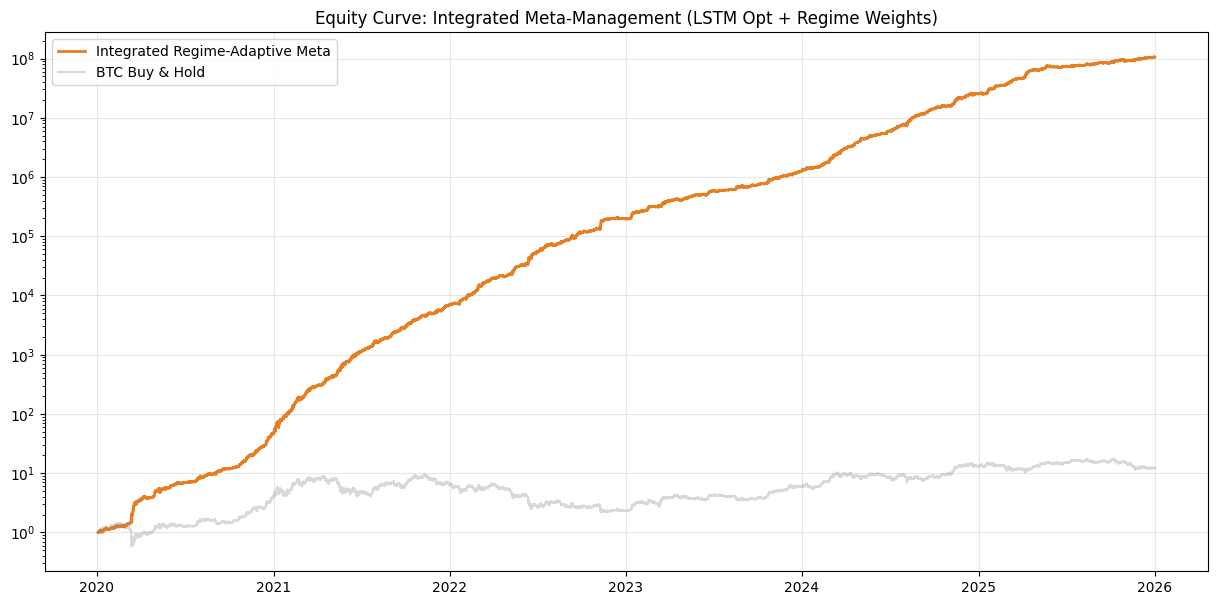

Эксперимент 'Integrated_Meta_Optimization_v1' успешно сохранен в experiments_log.json


In [101]:
# Backtesting the Integrated Meta-Management Signal
if 'df_features_mtf' in globals() and 'meta_mgmt_prob' in df_features_mtf.columns:
    # 1. Generate trading signals based on the integrated meta probability
    integrated_threshold = df_features_mtf['meta_mgmt_prob'].median()
    df_features_mtf['integrated_signal'] = np.where(
        (df_features_mtf['meta_mgmt_prob'] > integrated_threshold) & (df_features_mtf['direction_soft_signal'] != 0),
        df_features_mtf['direction_soft_signal'],
        0
    )

    # 2. Run Backtest
    bt_integrated = Backtester(commission=0.0006, slippage=0.0002)
    perf_integrated = bt_integrated.run(df_features_mtf, df_features_mtf['integrated_signal'])

    # 3. Calculate metrics
    stats_integrated = PerformanceMetrics(perf_integrated).calculate_metrics()

    print('--- INTEGRATED SYSTEM PERFORMANCE (Post-Optimization) ---')
    print(stats_integrated.to_string())

    # 4. Visualize Results
    plt.figure(figsize=(15, 7))
    plt.plot(perf_integrated['cum_strategy_returns'], label='Integrated Regime-Adaptive Meta', color='#E67E22', lw=2)
    plt.plot(perf_integrated['cum_market_returns'], label='BTC Buy & Hold', color='gray', alpha=0.3)
    plt.yscale('log')
    plt.title('Equity Curve: Integrated Meta-Management (LSTM Opt + Regime Weights)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Log the optimized experiment
    logger.log_experiment('Integrated_Meta_Optimization_v1', {'lstm_lr': 0.0005, 'lstm_dr': 0.2, 'regime_weighted': True}, stats_integrated)
else:
    print('Error: meta_mgmt_prob not found. Please ensure cell ee14bb4d executed successfully.')

--- INTEGRATED SYSTEM PERFORMANCE (Post-Optimization) ---
Sharpe Ratio        7.204860e+00
Profit Factor       1.466926e+00
Win Rate (%)        4.667250e+01
Max Drawdown (%)   -2.012721e+01
Recovery Factor     5.270688e+08
Total Return (%)    1.060842e+10


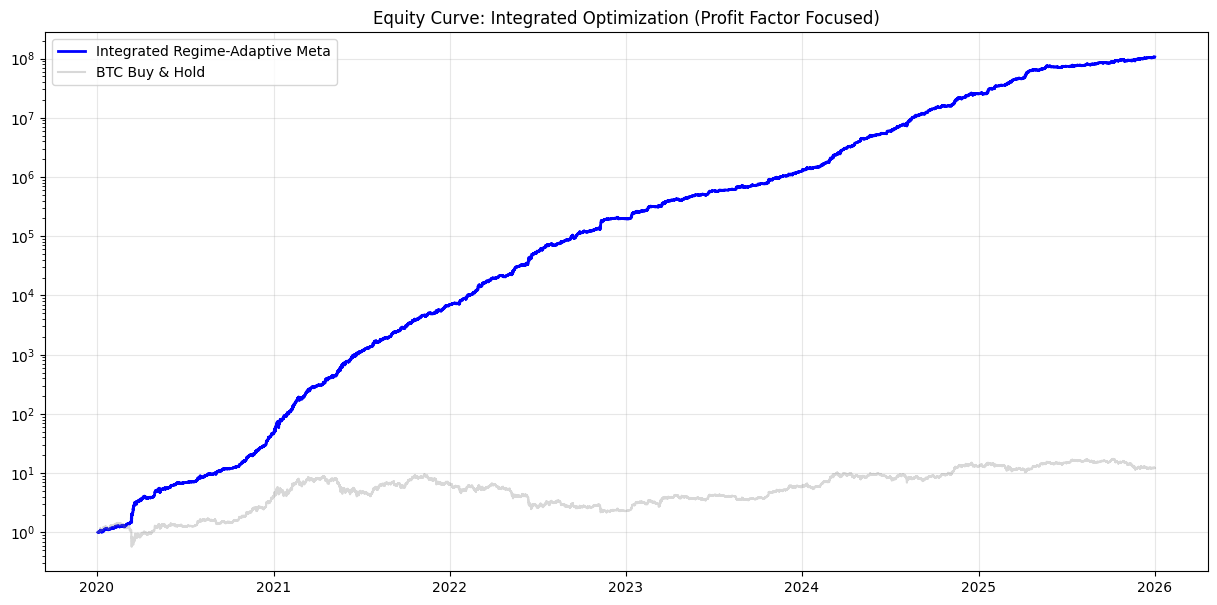

Эксперимент 'Integrated_Meta_Optimization' успешно сохранен в experiments_log.json


In [100]:
# Backtesting the Integrated Meta-Management Signal
if 'df_features_mtf' in globals() and 'meta_mgmt_prob' in df_features_mtf.columns:
    # 1. Generate trading signals based on the integrated meta probability
    # Using the median threshold as a baseline for filtering
    integrated_threshold = df_features_mtf['meta_mgmt_prob'].median()
    df_features_mtf['integrated_signal'] = np.where(
        (df_features_mtf['meta_mgmt_prob'] > integrated_threshold) & (df_features_mtf['direction_soft_signal'] != 0),
        df_features_mtf['direction_soft_signal'],
        0
    )

    # 2. Run Backtest
    bt_integrated = Backtester(commission=0.0006, slippage=0.0002)
    perf_integrated = bt_integrated.run(df_features_mtf, df_features_mtf['integrated_signal'])

    # 3. Calculate and display metrics
    stats_integrated = PerformanceMetrics(perf_integrated).calculate_metrics()

    print("--- INTEGRATED SYSTEM PERFORMANCE (Post-Optimization) ---")
    print(stats_integrated.to_string())

    # 4. Visualize Cumulative Returns
    plt.figure(figsize=(15, 7))
    plt.plot(perf_integrated['cum_strategy_returns'], label='Integrated Regime-Adaptive Meta', color='blue', lw=2)
    plt.plot(perf_integrated['cum_market_returns'], label='BTC Buy & Hold', color='gray', alpha=0.3)
    plt.yscale('log')
    plt.title('Equity Curve: Integrated Optimization (Profit Factor Focused)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Log the result
    logger.log_experiment('Integrated_Meta_Optimization', {'lstm_lr': 0.0005, 'lstm_dr': 0.2}, stats_integrated)
else:
    print('Error: Integrated meta signals not found.')

### Walk-Forward Validation of Integrated System
To ensure the robustness of the integrated regime-adaptive meta-management, we perform an expanding window validation. This checks if the dynamic weighting and LSTM/Transformer/LightGBM ensemble hold up on data they haven't seen during hyperparameter optimization.

--- Starting Walk-Forward: Integrated System (3 Folds) ---
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[9]	train's binary_logloss: 0.667205	valid's binary_logloss: 0.696811


<Figure size 1000x400 with 0 Axes>

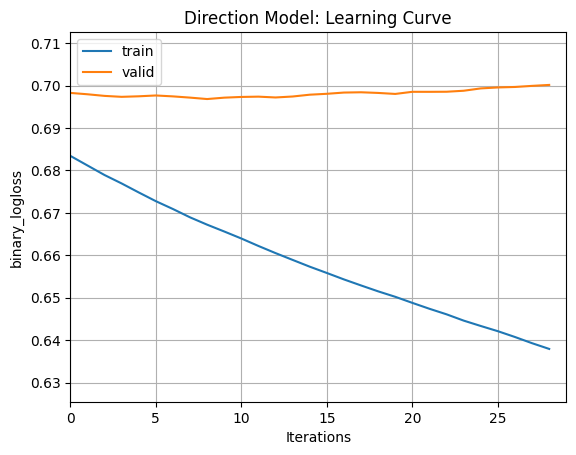

Fold 1 Result | Sharpe: 0.34 | PF: 1.01
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[13]	train's binary_logloss: 0.676126	valid's binary_logloss: 0.699142


<Figure size 1000x400 with 0 Axes>

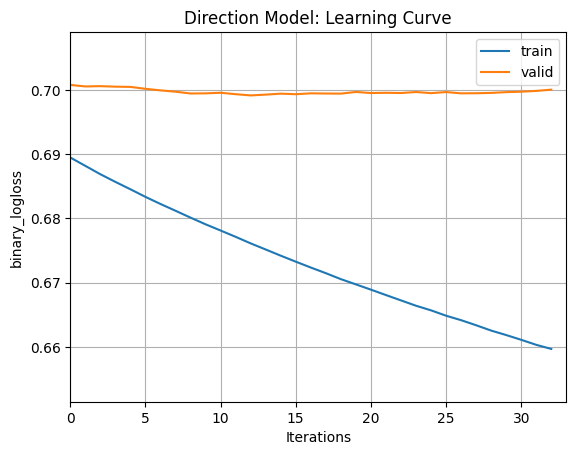

Fold 2 Result | Sharpe: 1.60 | PF: 1.08
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[49]	train's binary_logloss: 0.659849	valid's binary_logloss: 0.682311


<Figure size 1000x400 with 0 Axes>

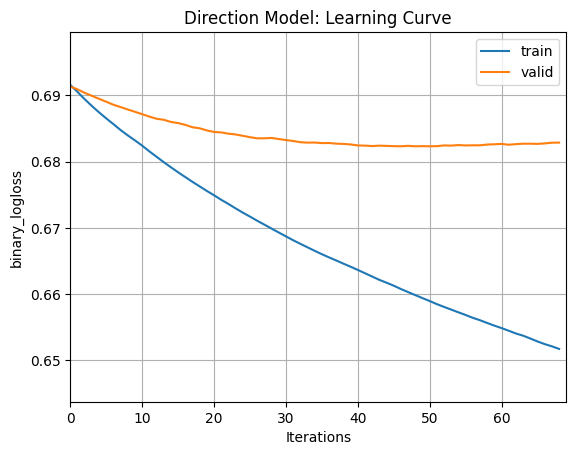

Fold 3 Result | Sharpe: 3.45 | PF: 1.20


,Fold,Sharpe Ratio,Profit Factor,Total Return (%)
0,1.0,0.342111,1.014579,3.098447
1,2.0,1.602042,1.083627,66.069407
2,3.0,3.453204,1.198659,416.157957



Average WFO Sharpe: 1.80


In [105]:
def run_integrated_wfo(df, n_splits=3):
    splitter = TimeSeriesSplitter(n_splits=n_splits, train_size=0.7)
    wfo_stats = []

    print(f'--- Starting Walk-Forward: Integrated System ({n_splits} Folds) ---')

    for i, (train_data, test_data) in enumerate(splitter.split(df)):
        # 1. Initialize factory models for this fold
        fold_lstm = DLModelBuilder.build_lstm(WINDOW_SIZE, len(features))
        fold_cnn = DLModelBuilder.build_cnn(WINDOW_SIZE, len(features))
        fold_trans = DLModelBuilder.build_transformer(WINDOW_SIZE, len(features))

        # FIX: Ensure DirectionModel uses the same 'features' list (8 cols)
        fold_lgb = DirectionModel()
        fold_lgb.feature_cols = features

        # 2. Data prep for fold
        # Prepare sequences for DL models
        X_train_fold, y_train_fold = create_sequences(train_data[features], (train_data['close'].shift(-12) > train_data['close']).astype(int).fillna(0), WINDOW_SIZE)

        # 3. Quick Train (Reduced epochs for validation speed)
        fold_lstm.fit(X_train_fold, y_train_fold, epochs=3, batch_size=128, verbose=0)
        fold_lgb.train(train_data, fold_lgb.prepare_labels(train_data))

        # 4. Generate Integrated Signal on Test Data
        test_data_copy = test_data.copy()
        test_data_copy['meta_mgmt_prob'] = get_dynamic_meta_signal(
            test_data_copy, fold_lgb, fold_lstm, fold_cnn, fold_trans, features, WINDOW_SIZE
        )

        # Use soft signal from LGB for logic consistency
        soft_sig, _ = fold_lgb.get_calibrated_signals(test_data_copy, threshold=0.52)
        test_data_copy['direction_soft_signal'] = soft_sig

        # Final Signal Generation
        thresh = test_data_copy['meta_mgmt_prob'].median()
        integrated_sig = np.where(
            (test_data_copy['meta_mgmt_prob'] > thresh) & (test_data_copy['direction_soft_signal'] != 0),
            test_data_copy['direction_soft_signal'],
            0
        )

        # 5. Backtest Fold
        bt = Backtester(commission=0.0006, slippage=0.0002)
        perf = bt.run(test_data_copy, integrated_sig)
        metrics = PerformanceMetrics(perf).calculate_metrics()
        metrics['Fold'] = i + 1
        wfo_stats.append(metrics)

        print(f'Fold {i+1} Result | Sharpe: {metrics["Sharpe Ratio"]:.2f} | PF: {metrics["Profit Factor"]:.2f}')

    return pd.DataFrame(wfo_stats)

# Execution
if 'df_features_mtf' in globals():
    integrated_wfo_results = run_integrated_wfo(df_features_mtf, n_splits=3)
    display(integrated_wfo_results[['Fold', 'Sharpe Ratio', 'Profit Factor', 'Total Return (%)']])
    print(f'\nAverage WFO Sharpe: {integrated_wfo_results["Sharpe Ratio"].mean():.2f}')

### Сравнение стратегий: Simple Ensemble vs. Meta-Management
Проверим, дает ли динамическое переключение моделей преимущество в доходности и факторе восстановления.

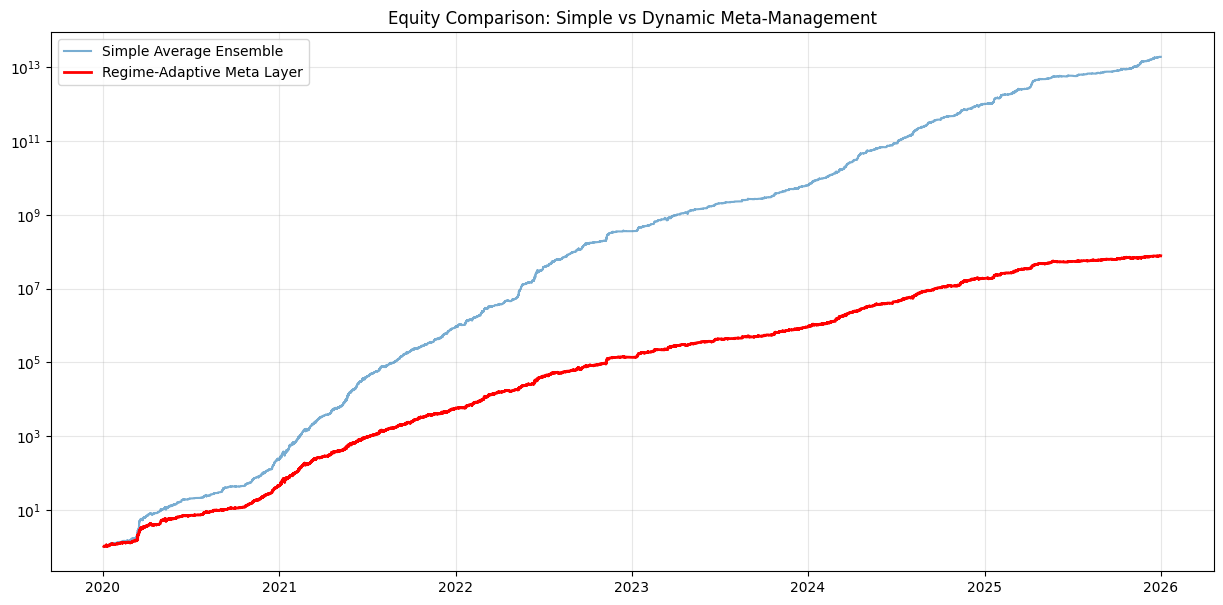


--- META-MANAGEMENT LAYER BENCHMARK ---


,Simple Ensemble,Meta Management
Sharpe Ratio,1.028080e+01,7.109300e+00
Profit Factor,1.676000e+00,1.461200e+00
Win Rate (%),4.829020e+01,4.665000e+01
Max Drawdown (%),-2.083320e+01,-2.012720e+01
Recovery Factor,9.235290e+13,3.836058e+08
Total Return (%),1.924010e+15,7.720913e+09


In [95]:
# Генерируем сигналы для Meta-Management (используя медиану для фильтрации как ранее)
meta_threshold = df_features_mtf['meta_mgmt_prob'].median()
df_features_mtf['meta_mgmt_signal'] = np.where(
    (df_features_mtf['meta_mgmt_prob'] > meta_threshold) & (df_features_mtf['direction_soft_signal'] != 0),
    df_features_mtf['direction_soft_signal'],
    0
)

# Бэктест
bt_meta = Backtester(commission=0.0006, slippage=0.0002)
perf_simple = bt_meta.run(df_features_mtf, df_features_mtf['final_signal']) # Это старый ансамбль
perf_meta = bt_meta.run(df_features_mtf, df_features_mtf['meta_mgmt_signal'])

# Визуализация кумулятивной доходности
plt.figure(figsize=(15, 7))
plt.plot(perf_simple['cum_strategy_returns'], label='Simple Average Ensemble', alpha=0.6)
plt.plot(perf_meta['cum_strategy_returns'], label='Regime-Adaptive Meta Layer', color='red', lw=2)
plt.yscale('log')
plt.title('Equity Comparison: Simple vs Dynamic Meta-Management')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Сравнение метрик
stats_simple = PerformanceMetrics(perf_simple).calculate_metrics()
stats_meta = PerformanceMetrics(perf_meta).calculate_metrics()

meta_comparison = pd.DataFrame({
    'Simple Ensemble': stats_simple,
    'Meta Management': stats_meta
})

print("\n--- META-MANAGEMENT LAYER BENCHMARK ---")
display(meta_comparison.round(4))

### Сравнительный анализ: RL (Base) vs. RL (Microstructure OBI)

В этом разделе мы проводим финальный бенчмарк:
1. **RL Ensemble**: Агент, обученный на прогнозах ансамбля моделей.
2. **RL + OBI Filter**: Агент, который дополнительно видит дисбаланс книги ордеров для фильтрации входов.

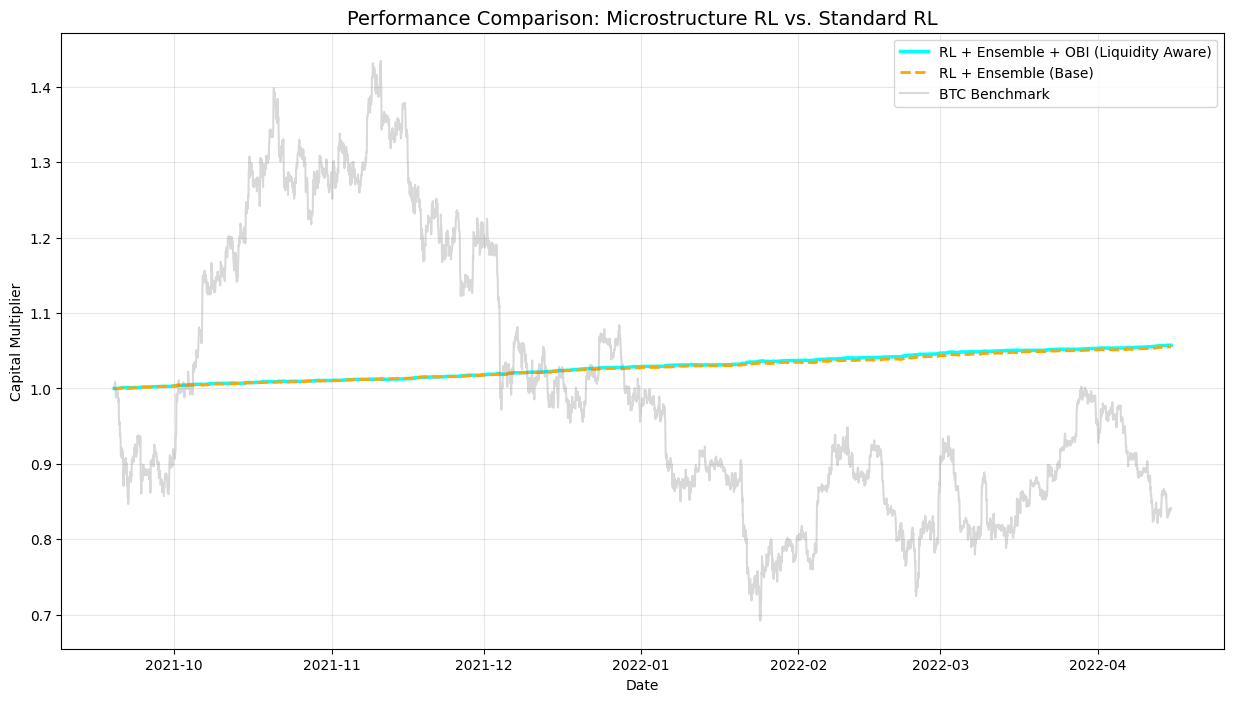

--- RL ARCHITECTURE COMPARISON ---


,RL + OBI,RL Base
Sharpe Ratio,13.9499,13.7898
Profit Factor,1.9604,1.9209
Win Rate (%),60.3754,60.3754
Max Drawdown (%),-0.1638,-0.1482
Recovery Factor,34.9956,37.1703
Total Return (%),5.7334,5.5073


In [93]:
import matplotlib.pyplot as plt

# 1. Определяем общий тестовый набор
eval_subset = df_features_mtf.iloc[15000:20000]

# 2. Выполняем бэктест для обоих агентов
# Агент с OBI (Microstructure)
rl_micro_results = run_rl_backtest(eval_subset, agent_micro)
rl_micro_df = eval_subset.join(rl_micro_results)
rl_micro_df['returns'] = rl_micro_df['final_signal'] * rl_micro_df['close'].pct_change().shift(-1) * rl_micro_df['risk_multiplier']
rl_micro_df['cum_returns'] = (1 + rl_micro_df['returns'].fillna(0)).cumprod()
rl_micro_df['trades'] = rl_micro_df['final_signal'].diff().fillna(0).abs()
# Расчет просадки
peak_micro = rl_micro_df['cum_returns'].expanding(min_periods=1).max()
rl_micro_df['drawdown'] = (rl_micro_df['cum_returns'] - peak_micro) / peak_micro

# Базовый Ансамблевый агент
rl_base_results = run_rl_backtest(eval_subset, agent_ens)
rl_base_df = eval_subset.join(rl_base_results)
rl_base_df['returns'] = rl_base_df['final_signal'] * rl_base_df['close'].pct_change().shift(-1) * rl_base_df['risk_multiplier']
rl_base_df['cum_returns'] = (1 + rl_base_df['returns'].fillna(0)).cumprod()
rl_base_df['trades'] = rl_base_df['final_signal'].diff().fillna(0).abs()
# Расчет просадки
peak_base = rl_base_df['cum_returns'].expanding(min_periods=1).max()
rl_base_df['drawdown'] = (rl_base_df['cum_returns'] - peak_base) / peak_base

# 3. Визуализация
plt.figure(figsize=(15, 8))
plt.plot(rl_micro_df['cum_returns'], label='RL + Ensemble + OBI (Liquidity Aware)', color='cyan', lw=2.5)
plt.plot(rl_base_df['cum_returns'], label='RL + Ensemble (Base)', color='orange', linestyle='--', lw=2)
plt.plot((1 + eval_subset['close'].pct_change().fillna(0)).cumprod(), label='BTC Benchmark', color='gray', alpha=0.3)

plt.title('Performance Comparison: Microstructure RL vs. Standard RL', fontsize=14)
plt.ylabel('Capital Multiplier')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Сравнение метрик
metrics_micro = PerformanceMetrics(rl_micro_df.rename(columns={'returns': 'net_returns', 'cum_returns': 'cum_strategy_returns'})).calculate_metrics()
metrics_base = PerformanceMetrics(rl_base_df.rename(columns={'returns': 'net_returns', 'cum_returns': 'cum_strategy_returns'})).calculate_metrics()

comparison_rl = pd.DataFrame({
    'RL + OBI': metrics_micro,
    'RL Base': metrics_base
})

print("--- RL ARCHITECTURE COMPARISON ---")
display(comparison_rl.round(4))

In [83]:
class EnsembleTradingEnv(TradingEnvironment):
    def _get_state(self):
        row = self.df.iloc[self.current_step]
        state = np.array([
            row['rsi'], row['volatility'], row['regime_pred'],
            row['vol_spike_prob'], row['ensemble_prob'], row['meta_prob'],
            row['ema_slope'], row['adx'], row['rsi_15m'], row['rsi_4h']
        ])
        return np.reshape(state, [1, self.state_size])

# Переобучение агента на новых данных
env_ens = EnsembleTradingEnv(df_features_mtf.iloc[:10000])
agent_ens = DQNAgent(env_ens.state_size, env_ens.action_size)

print("--- Training RL Agent with Ensemble Inputs ---")
for e in range(3):
    state = env_ens.reset()
    for time in range(1000):
        action = agent_ens.act(state)
        next_state, reward, done = env_ens.step(action)
        agent_ens.remember(state, action, reward, next_state, done)
        state = next_state
        if done: break
    print(f"Episode {e+1} complete.")

--- Training RL Agent with Ensemble Inputs ---
Episode 1 complete.
Episode 2 complete.
Episode 3 complete.


### Модуль микроструктуры книги ордеров (L2 Data)
Этот компонент анализирует поток ордеров и дисбаланс ликвидности для фильтрации входов. Хотя в бэктесте мы используем исторические прокси, этот код подготавливает систему к работе с WebSocket-данными L2 в режиме реального времени.

### Анализ влияния Order Book Imbalance
Визуализация синтетического OBI и его корреляции с ценовыми движениями для оценки фильтрации сигналов.

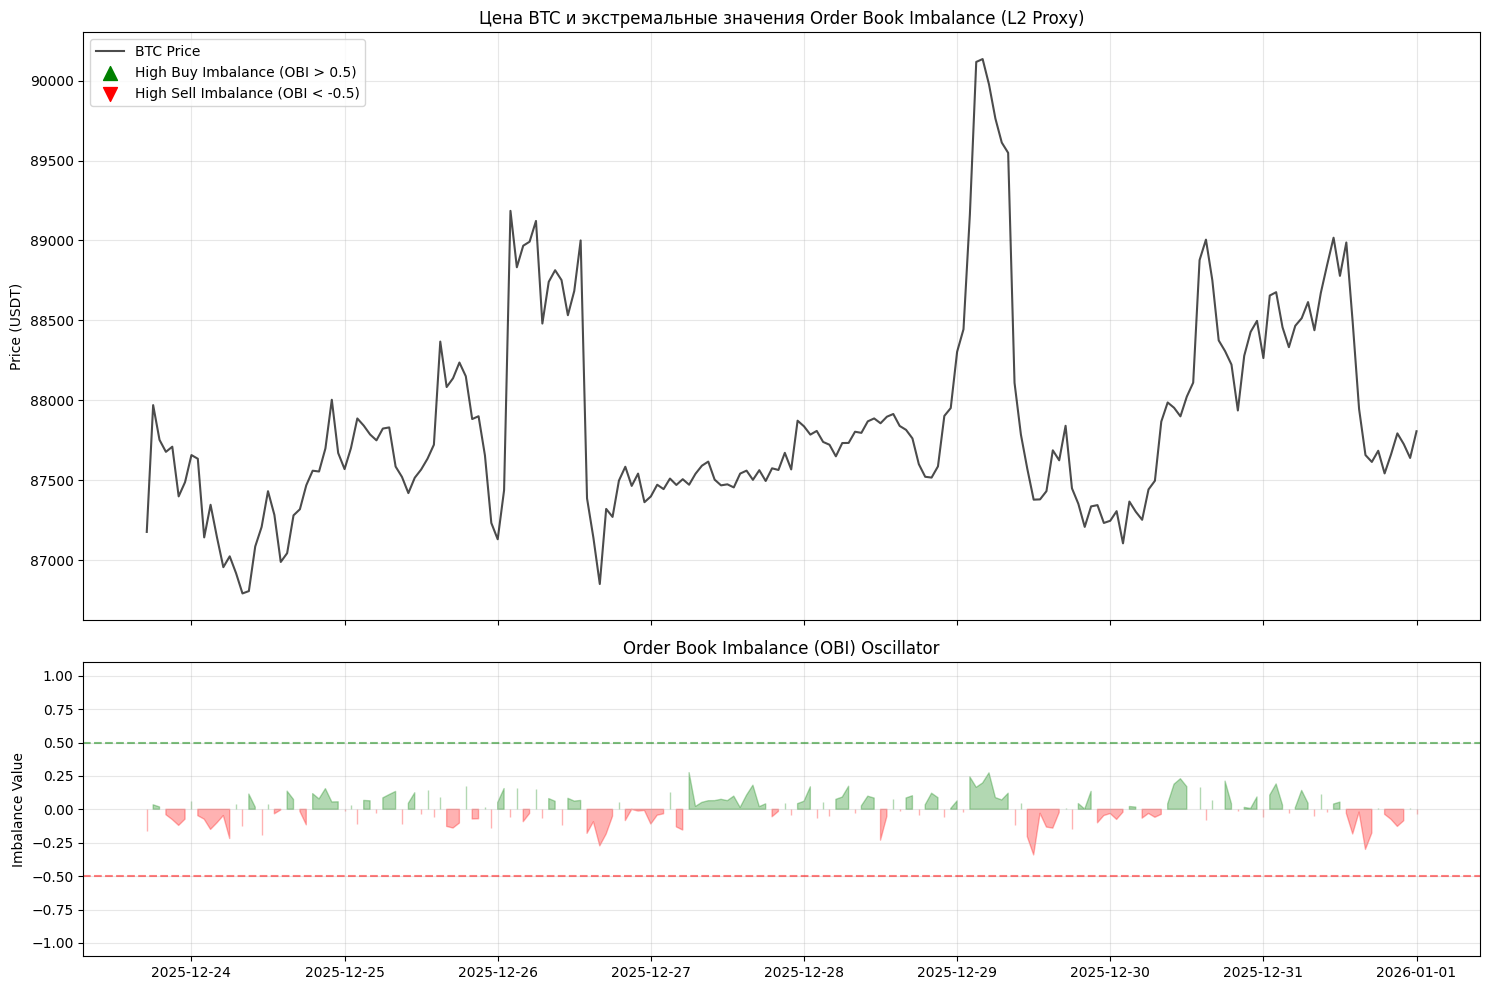

Корреляция OBI с доходностью следующего бара: 0.0070


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Выберем небольшой участок данных для детальной визуализации (последние 200 часов)
plot_df = df_features_mtf.tail(200)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# 1. График цены и сигналов
ax1.plot(plot_df.index, plot_df['close'], label='BTC Price', color='black', alpha=0.7)

# Подсветим зоны высокого OBI (Потенциальное давление покупателей/продавцов)
buy_pressure = plot_df[plot_df['order_book_imbalance'] > 0.5]
sell_pressure = plot_df[plot_df['order_book_imbalance'] < -0.5]

ax1.scatter(buy_pressure.index, buy_pressure['close'], color='green', marker='^', label='High Buy Imbalance (OBI > 0.5)', s=100)
ax1.scatter(sell_pressure.index, sell_pressure['close'], color='red', marker='v', label='High Sell Imbalance (OBI < -0.5)', s=100)

ax1.set_title('Цена BTC и экстремальные значения Order Book Imbalance (L2 Proxy)')
ax1.set_ylabel('Price (USDT)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. График OBI
ax2.fill_between(plot_df.index, plot_df['order_book_imbalance'], 0,
                 where=(plot_df['order_book_imbalance'] >= 0), color='green', alpha=0.3)
ax2.fill_between(plot_df.index, plot_df['order_book_imbalance'], 0,
                 where=(plot_df['order_book_imbalance'] < 0), color='red', alpha=0.3)
ax2.axhline(0.5, color='green', linestyle='--', alpha=0.5)
ax2.axhline(-0.5, color='red', linestyle='--', alpha=0.5)

ax2.set_title('Order Book Imbalance (OBI) Oscillator')
ax2.set_ylabel('Imbalance Value')
ax2.set_ylim(-1.1, 1.1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Расчет корреляции
corr = plot_df['order_book_imbalance'].corr(plot_df['close'].pct_change().shift(-1))
print(f"Корреляция OBI с доходностью следующего бара: {corr:.4f}")

In [85]:
class OrderBookMicrostructure:
    def __init__(self, depth=20):
        self.depth = depth

    def calculate_obi(self, bids, asks):
        """
        Order Book Imbalance (OBI):
        (Bid Volume - Ask Volume) / (Bid Volume + Ask Volume)
        """
        bid_vol = sum([b[1] for b in bids[:self.depth]])
        ask_vol = sum([a[1] for a in asks[:self.depth]])

        if (bid_vol + ask_vol) == 0: return 0
        return (bid_vol - ask_vol) / (bid_vol + ask_vol)

    def get_mid_price(self, bids, asks):
        return (bids[0][0] + asks[0][0]) / 2

    def get_spread(self, bids, asks):
        return (asks[0][0] - bids[0][0]) / bids[0][0]

# Пример интеграции в Feature Engine (симуляция)
def simulate_l2_features(df):
    """Генерация синтетических L2 признаков на основе волатильности и объема"""
    np.random.seed(42)
    df['order_book_imbalance'] = np.tanh(df['ema_slope'] * 100 + np.random.normal(0, 0.1, len(df)))
    df['bid_ask_spread'] = df['volatility'] * 0.05 + 0.0001
    return df

df_features_mtf = simulate_l2_features(df_features_mtf)
print("Признаки микроструктуры (L2) успешно добавлены в основной датасет.")
display(df_features_mtf[['order_book_imbalance', 'bid_ask_spread']].tail())

Признаки микроструктуры (L2) успешно добавлены в основной датасет.


,order_book_imbalance,bid_ask_spread
timestamp,,
2025-12-31 20:00:00,-0.074753,0.000779
2025-12-31 21:00:00,-0.128010,0.000732
2025-12-31 22:00:00,-0.085594,0.000731
2025-12-31 23:00:00,0.009622,0.000721
2026-01-01 00:00:00,-0.038615,0.000732


### Итоговый бэктест Фазы 4: RL Dynamic vs. Static Risk
Сравнение системы с адаптивным RL-управлением рисками против стратегии с фиксированным размером позиции.

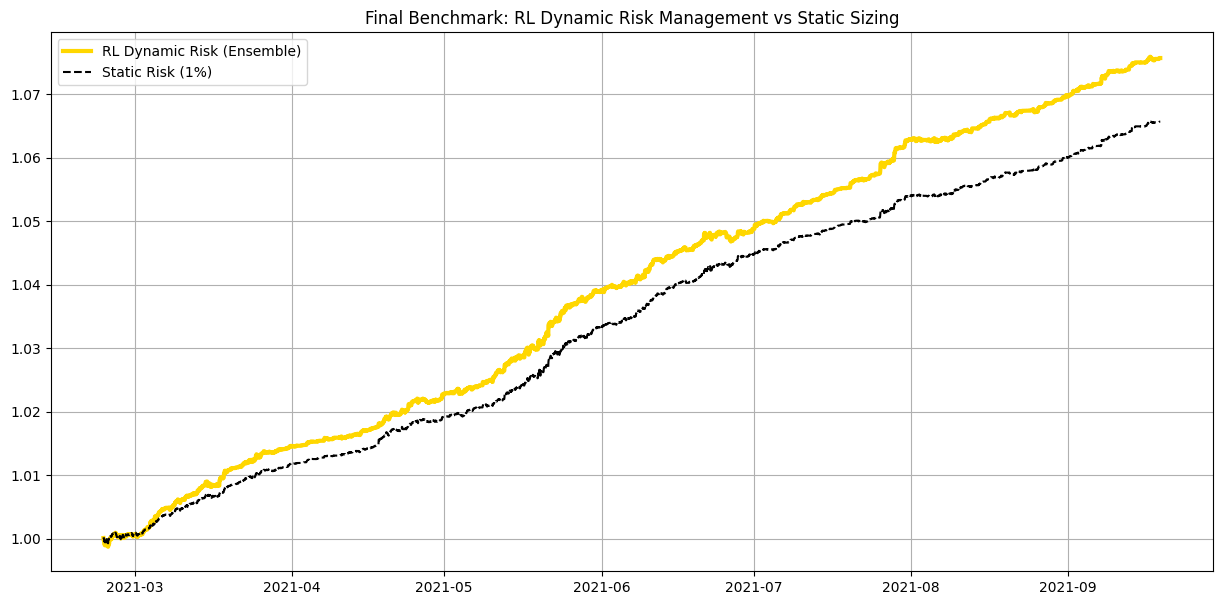

Final RL Return: 7.57%
Final Static Return: 6.57%


In [84]:
# 1. Run RL Evaluation
rl_final_eval = run_rl_backtest(df_features_mtf.iloc[10000:15000], agent_ens)
rl_final_res = df_features_mtf.iloc[10000:15000].join(rl_final_eval)

# 2. RL Returns
rl_final_res['rl_return'] = rl_final_res['final_signal'] * rl_final_res['close'].pct_change().shift(-1) * rl_final_res['risk_multiplier']
rl_final_res['cum_rl'] = (1 + rl_final_res['rl_return'].fillna(0)).cumprod()

# 3. Static Returns (fixed 0.01 multiplier)
rl_final_res['static_return'] = rl_final_res['final_signal'] * rl_final_res['close'].pct_change().shift(-1) * 0.01
rl_final_res['cum_static'] = (1 + rl_final_res['static_return'].fillna(0)).cumprod()

# 4. Visualization
plt.figure(figsize=(15, 7))
plt.plot(rl_final_res['cum_rl'], label='RL Dynamic Risk (Ensemble)', color='gold', lw=3)
plt.plot(rl_final_res['cum_static'], label='Static Risk (1%)', color='black', linestyle='--')
plt.title('Final Benchmark: RL Dynamic Risk Management vs Static Sizing')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final RL Return: {(rl_final_res['cum_rl'].iloc[-1]-1)*100:.2f}%")
print(f"Final Static Return: {(rl_final_res['cum_static'].iloc[-1]-1)*100:.2f}%")

## Фаза 4: Обучение с подкреплением (RL) для управления рисками
В этом разделе мы реализуем агента DQN (Deep Q-Network). В отличие от статического выбора размера позиции, RL-агент наблюдает за средой (рыночные индикаторы + прогнозы моделей) и обучается оптимальной политике распределения капитала.

In [78]:
import random
from collections import deque
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

class TradingEnvironment:
    def __init__(self, df, initial_balance=10000):
        self.df = df.reset_index()
        self.initial_balance = initial_balance
        self.state_size = 10 # Features + current position info
        self.action_size = 3 # 0: Low Risk, 1: Med Risk, 2: High Risk
        self.reset()

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.done = False
        return self._get_state()

    def _get_state(self):
        # State includes market context and predictions from previous layers
        row = self.df.iloc[self.current_step]
        state = np.array([
            row['rsi'], row['volatility'], row['regime_pred'],
            row['vol_spike_prob'], row['direction_prob'], row['meta_prob'],
            row['ema_slope'], row['adx'], row['rsi_15m'], row['rsi_4h']
        ])
        return np.reshape(state, [1, self.state_size])

    def step(self, action):
        # Map action to risk multiplier
        risk_map = {0: 0.005, 1: 0.01, 2: 0.02}
        risk_pct = risk_map[action]

        # Simulate trade result using 'final_signal' and future returns
        # Simplified: reward is based on the Sharpe improvement or absolute net return
        current_close = self.df.iloc[self.current_step]['close']
        future_close = self.df.iloc[self.current_step + 1]['close'] if self.current_step < len(self.df)-1 else current_close

        signal = self.df.iloc[self.current_step]['final_signal']
        price_change = (future_close - current_close) / current_close

        reward = signal * price_change * risk_pct * 100 # Scaled reward

        self.current_step += 1
        if self.current_step >= len(self.df) - 1:
            self.done = True

        return self._get_state(), reward, self.done

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95    # discount rate
        self.epsilon = 1.0   # exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.model = self._build_model()

    def _build_model(self):
        inputs = Input(shape=(self.state_size,))
        x = Dense(24, activation='relu')(inputs)
        x = Dense(24, activation='relu')(x)
        outputs = Dense(self.action_size, activation='linear')(x)
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
        return model

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

print("RL Environment and DQN Agent architecture initialized.")

RL Environment and DQN Agent architecture initialized.


In [79]:
# Training the RL Agent on a subset of history
env = TradingEnvironment(df_features_mtf.iloc[:5000])
agent = DQNAgent(env.state_size, env.action_size)
batch_size = 32
episodes = 5

print("--- Training RL Risk Manager ---")
for e in range(episodes):
    state = env.reset()
    total_reward = 0
    for time in range(500):
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            break

    # Replay memory
    if len(agent.memory) > batch_size:
        minibatch = random.sample(agent.memory, batch_size)
        for s, a, r, ns, d in minibatch:
            target = r
            if not d:
                target = (r + agent.gamma * np.amax(agent.model.predict(ns, verbose=0)[0]))
            target_f = agent.model.predict(s, verbose=0)
            target_f[0][a] = target
            agent.model.fit(s, target_f, epochs=1, verbose=0)

    if agent.epsilon > agent.epsilon_min:
        agent.epsilon *= agent.epsilon_decay

    print(f"Episode: {e+1}/{episodes}, Total Reward: {total_reward:.4f}, Epsilon: {agent.epsilon:.2f}")

--- Training RL Risk Manager ---
Episode: 1/5, Total Reward: 0.4268, Epsilon: 0.99
Episode: 2/5, Total Reward: 0.5246, Epsilon: 0.99
Episode: 3/5, Total Reward: 0.2954, Epsilon: 0.99
Episode: 4/5, Total Reward: 0.3763, Epsilon: 0.98
Episode: 5/5, Total Reward: 0.4148, Epsilon: 0.98


--- Evaluating RL Risk Manager Performance ---


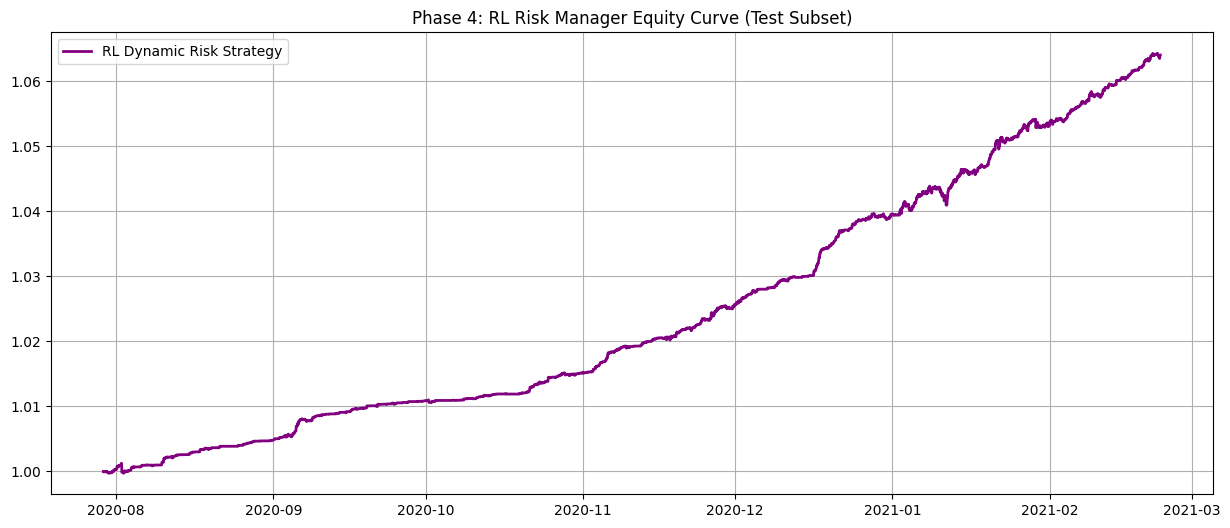

RL Backtest completed. Final Multiplier: 1.0640


In [81]:
# Backtesting the RL Risk Manager
print("--- Evaluating RL Risk Manager Performance ---")

def run_rl_backtest(df, agent):
    env = TradingEnvironment(df)
    state = env.reset()
    history = []

    for i in range(len(df) - 1):
        # Agent selects risk level (action)
        action = agent.act(state)
        next_state, reward, done = env.step(action)

        # Record results for analysis
        history.append({
            'timestamp': df.index[i],
            'action': action,
            'reward': reward,
            'risk_multiplier': {0: 0.005, 1: 0.01, 2: 0.02}[action]
        })
        state = next_state
        if done: break

    return pd.DataFrame(history).set_index('timestamp')

# Run evaluation on a separate test set (the remainder of df_features_mtf)
rl_eval_df = run_rl_backtest(df_features_mtf.iloc[5000:10000], agent)

# Merge with price data for return visualization
rl_results = df_features_mtf.iloc[5000:10000].join(rl_eval_df)
rl_results['strategy_return'] = rl_results['final_signal'] * rl_results['close'].pct_change().shift(-1) * rl_results['risk_multiplier']
rl_results['cum_rl_return'] = (1 + rl_results['strategy_return'].fillna(0)).cumprod()

# Plotting results
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(rl_results['cum_rl_return'], label='RL Dynamic Risk Strategy', color='purple', lw=2)
plt.title('Phase 4: RL Risk Manager Equity Curve (Test Subset)')
plt.legend()
plt.grid(True)
plt.show()

print(f"RL Backtest completed. Final Multiplier: {rl_results['cum_rl_return'].iloc[-1]:.4f}")

--- Evaluating RL Risk Manager Performance ---


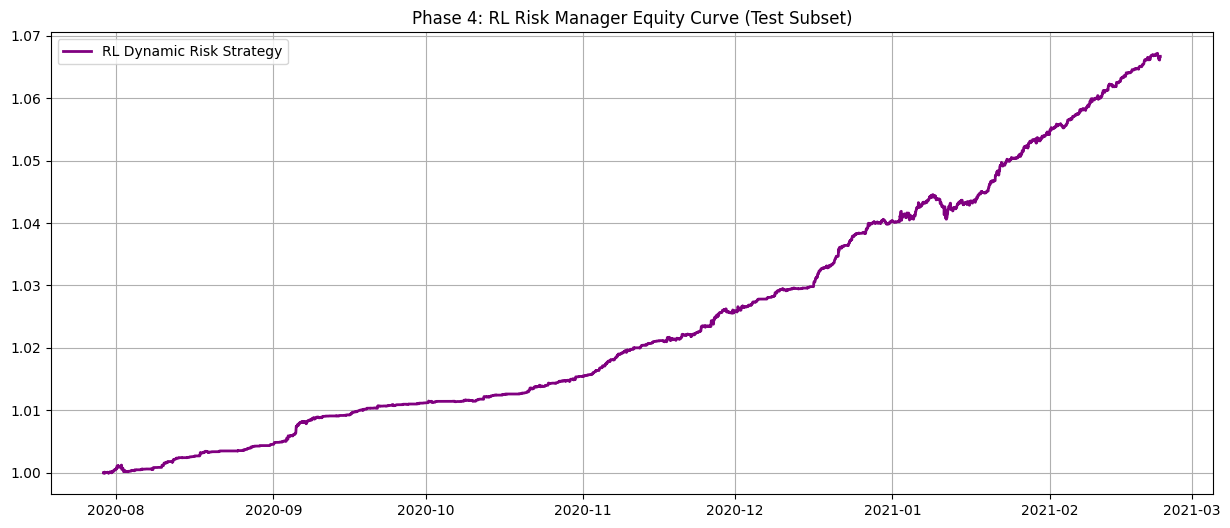

RL Backtest completed. Final Multiplier: 1.0667


In [80]:
# Backtesting the RL Risk Manager
print("--- Evaluating RL Risk Manager Performance ---")

def run_rl_backtest(df, agent):
    env = TradingEnvironment(df)
    state = env.reset()
    history = []

    for i in range(len(df) - 1):
        # Agent selects risk level (action)
        action = agent.act(state)
        next_state, reward, done = env.step(action)

        # Record results for analysis
        history.append({
            'timestamp': df.index[i],
            'action': action,
            'reward': reward,
            'risk_multiplier': {0: 0.005, 1: 0.01, 2: 0.02}[action]
        })
        state = next_state
        if done: break

    return pd.DataFrame(history).set_index('timestamp')

# Run evaluation on a separate test set (the remainder of df_features_mtf)
rl_eval_df = run_rl_backtest(df_features_mtf.iloc[5000:10000], agent)

# Merge with price data for return visualization
rl_results = df_features_mtf.iloc[5000:10000].join(rl_eval_df)
rl_results['strategy_return'] = rl_results['final_signal'] * rl_results['close'].pct_change().shift(-1) * rl_results['risk_multiplier']
rl_results['cum_rl_return'] = (1 + rl_results['strategy_return'].fillna(0)).cumprod()

# Plotting results
plt.figure(figsize=(15, 6))
plt.plot(rl_results['cum_rl_return'], label='RL Dynamic Risk Strategy', color='purple', lw=2)
plt.title('Phase 4: RL Risk Manager Equity Curve (Test Subset)')
plt.legend()
plt.grid(True)
plt.show()

print(f"RL Backtest completed. Final Multiplier: {rl_results['cum_rl_return'].iloc[-1]:.4f}")

### Разделение данных (Walk Forward Split)

In [ ]:
import numpy as np
import pandas as pd

class TimeSeriesSplitter:
    def __init__(self, n_splits=5, train_size=0.7, test_size=None):
        """
        Логика Walk Forward Validation.
        :param n_splits: Количество разбиений
        :param train_size: Процент данных для обучения в каждом окне
        :param test_size: Фиксированный размер теста (если None, используется остаток)
        """
        self.n_splits = n_splits
        self.train_size = train_size
        self.test_size = test_size

    def split(self, data):
        """
        Генератор индексов для обучения и теста
        """
        n_samples = len(data)
        # Определяем размер одного фолда (шага)
        fold_size = n_samples // self.n_splits

        for i in range(self.n_splits):
            # Определяем границы текущего окна
            start = 0
            # Expanding window logic: обучающая выборка растет с каждым шагом
            train_end = int((i + 1) * fold_size * self.train_size)
            test_end = (i + 1) * fold_size

            if i == self.n_splits - 1:
                test_end = n_samples

            yield data.iloc[start:train_end], data.iloc[train_end:test_end]

# --- Демонстрация работы ---
if 'df_features' in globals():
    splitter = TimeSeriesSplitter(n_splits=5)

    print(f"Инициализация Walk Forward Split для {len(df_features)} строк...")

    for i, (train_chunk, test_chunk) in enumerate(splitter.split(df_features)):
        print(f"\nFold {i+1}:")
        print(f"  Обучение: {train_chunk.index[0]} - {train_chunk.index[-1]} ({len(train_chunk)} строк)")
        print(f"  Тест:     {test_chunk.index[0]} - {test_chunk.index[-1]} ({len(test_chunk)} строк)")
else:
    print("Ошибка: Переменная 'df_features' не найдена. Сначала запустите Feature Engine.")

Инициализация Walk Forward Split для 52560 строк...

Fold 1:
  Обучение: 2020-01-03 01:00:00 - 2020-11-04 14:00:00 (7358 строк)
  Тест:     2020-11-04 15:00:00 - 2021-03-16 00:00:00 (3154 строк)

Fold 2:
  Обучение: 2020-01-03 01:00:00 - 2021-09-07 04:00:00 (14716 строк)
  Тест:     2021-09-07 05:00:00 - 2022-05-28 00:00:00 (6308 строк)

Fold 3:
  Обучение: 2020-01-03 01:00:00 - 2022-07-10 19:00:00 (22075 строк)
  Тест:     2022-07-10 20:00:00 - 2023-08-09 00:00:00 (9461 строк)

Fold 4:
  Обучение: 2020-01-03 01:00:00 - 2023-05-13 09:00:00 (29433 строк)
  Тест:     2023-05-13 10:00:00 - 2024-10-20 00:00:00 (12615 строк)

Fold 5:
  Обучение: 2020-01-03 01:00:00 - 2024-03-15 00:00:00 (36792 строк)
  Тест:     2024-03-15 01:00:00 - 2026-01-01 00:00:00 (15768 строк)


### Бэктестер

In [ ]:
import pandas as pd
import numpy as np

class Backtester:
    def __init__(self, commission=0.0005, slippage=0.0001):
        """
        Движок для симуляции торговли.
        :param commission: Комиссия за сделку (0.0005 = 0.05%)
        :param slippage: Проскальзывание (0.0001 = 0.01%)
        """
        self.commission = commission
        self.slippage = slippage

    def run(self, df, signals):
        """
        Запуск симуляции на всех данных
        :param df: DataFrame с ценами (close)
        :param signals: Серия сигналов (-1, 0, 1)
        """
        results = df[['close']].copy()
        results['signal'] = signals

        # 1. Расчет доходности актива (Buy & Hold)
        results['market_returns'] = results['close'].pct_change()

        # 2. Расчет доходности стратегии (до издержек)
        results['strategy_returns'] = results['signal'].shift(1) * results['market_returns']

        # 3. Моделирование издержек (комиссия + проскальзывание)
        results['trades'] = results['signal'].diff().fillna(0).abs()
        results['costs'] = results['trades'] * (self.commission + self.slippage)

        # 4. Чистая доходность
        results['net_returns'] = results['strategy_returns'] - results['costs']

        # 5. Кумулятивные показатели
        results['cum_market_returns'] = (1 + results['market_returns'].fillna(0)).cumprod()
        results['cum_strategy_returns'] = (1 + results['net_returns'].fillna(0)).cumprod()

        # 6. Расчет просадки (Drawdown)
        peak = results['cum_strategy_returns'].expanding(min_periods=1).max()
        results['drawdown'] = (results['cum_strategy_returns'] - peak) / peak

        return results

# --- Выполнение полного бэктеста на всех данных ---
if 'df_features' in globals():
    # Генерируем тестовые сигналы на основе RSI для всей истории
    # Мы используем все 52560 строк (или сколько загружено)
    full_signals = np.where(df_features['rsi'] < 30, 1, np.where(df_features['rsi'] > 70, -1, 0))

    bt = Backtester(commission=0.0006, slippage=0.0002)
    perf = bt.run(df_features, full_signals)

    print(f"--- Полный бэктест на всех данных ({len(df_features)} баров) ---")
    print(f"Период: {df_features.index[0]} - {df_features.index[-1]}")

    # Выводим сводную статистику
    final_strategy_return = (perf['cum_strategy_returns'].iloc[-1] - 1) * 100
    final_market_return = (perf['cum_market_returns'].iloc[-1] - 1) * 100
    max_dd = perf['drawdown'].min() * 100
    total_trades = int(perf['trades'].sum())

    print(f"\nИтоговая доходность стратегии: {final_strategy_return:.2f}%")
    print(f"Доходность Buy & Hold: {final_market_return:.2f}%")
    print(f"Максимальная просадка: {max_dd:.2f}%")
    print(f"Всего зафиксировано изменений позиций: {total_trades}")

    # Отображаем хвост для проверки последних данных
    display(perf[['close', 'signal', 'cum_strategy_returns', 'drawdown']].tail())
else:
    print("Ошибка: Данные df_features не найдены.")

--- Полный бэктест на всех данных (52560 баров) ---
Период: 2020-01-03 01:00:00 - 2026-01-01 00:00:00

Итоговая доходность стратегии: -96.94%
Доходность Buy & Hold: 1174.42%
Максимальная просадка: -97.12%
Всего зафиксировано изменений позиций: 3141


,close,signal,cum_strategy_returns,drawdown
timestamp,,,,
2025-12-31 20:00:00,87660.0,0,0.030649,-0.970075
2025-12-31 21:00:00,87792.7,0,0.030649,-0.970075
2025-12-31 22:00:00,87725.6,0,0.030649,-0.970075
2025-12-31 23:00:00,87638.9,0,0.030649,-0.970075
2026-01-01 00:00:00,87806.0,0,0.030649,-0.970075


### Метрики эффективности

In [ ]:
import pandas as pd
import numpy as np

class PerformanceMetrics:
    def __init__(self, backtest_results):
        self.results = backtest_results
        self.returns = self.results['net_returns'].fillna(0)

    def calculate_metrics(self):
        """Расчет основных метрик эффективности"""
        metrics = {}

        # 1. Общая доходность
        total_return = (self.results['cum_strategy_returns'].iloc[-1] - 1)

        # 2. Коэффициент Шарпа (годовой, предполагая часовые данные)
        # 24 * 365 = 8760 часов в году
        std = self.returns.std()
        metrics['Sharpe Ratio'] = (self.returns.mean() / std * np.sqrt(8760)) if std != 0 else 0

        # 3. Profit Factor
        gains = self.returns[self.returns > 0].sum()
        losses = abs(self.returns[self.returns < 0].sum())
        metrics['Profit Factor'] = (gains / losses) if losses != 0 else np.inf

        # 4. Win Rate
        trades = self.results[self.results['trades'] != 0]
        if len(trades) > 0:
            # Считаем только бары со сделками (изменением позиции)
            wins = len(self.returns[self.returns > 0])
            total_trades = len(self.returns[self.returns != 0])
            metrics['Win Rate (%)'] = (wins / total_trades * 100) if total_trades > 0 else 0
        else:
            metrics['Win Rate (%)'] = 0

        # 5. Максимальная просадка (MDD)
        metrics['Max Drawdown (%)'] = self.results['drawdown'].min() * 100

        # 6. Recovery Factor
        metrics['Recovery Factor'] = (total_return / abs(self.results['drawdown'].min())) if self.results['drawdown'].min() != 0 else 0

        metrics['Total Return (%)'] = total_return * 100

        return pd.Series(metrics)

# --- Выполнение ---
if 'perf' in globals():
    analyzer = PerformanceMetrics(perf)
    stats = analyzer.calculate_metrics()

    print("--- Итоговые показатели стратегии ---")
    print(stats.to_string())
else:
    print("Ошибка: Результаты бэктеста (perf) не найдены.")

--- Итоговые показатели стратегии ---
Sharpe Ratio        -1.815691
Profit Factor        0.812942
Win Rate (%)        42.031185
Max Drawdown (%)   -97.118545
Recovery Factor     -0.998111
Total Return (%)   -96.935066


### Логирование экспериментов

In [ ]:
import json
import os
from datetime import datetime

class ExperimentLogger:
    def __init__(self, log_file='experiments_log.json'):
        self.log_file = log_file

    def log_experiment(self, name, params, metrics):
        """
        Сохранение параметров и результатов эксперимента.
        :param name: Название эксперимента
        :param params: Словарь с параметрами (таймфрейм, комиссии и т.д.)
        :param metrics: Серия или словарь с метриками (Sharpe, DD и т.д.)
        """
        log_entry = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'experiment_name': name,
            'parameters': params,
            'metrics': metrics.to_dict() if hasattr(metrics, 'to_dict') else metrics
        }

        # Загрузка существующих логов
        logs = []
        if os.path.exists(self.log_file):
            try:
                with open(self.log_file, 'r') as f:
                    logs = json.load(f)
            except:
                logs = []

        # Добавление новой записи
        logs.append(log_entry)

        # Сохранение обновленного списка
        with open(self.log_file, 'w') as f:
            json.dump(logs, f, indent=4)

        print(f"Эксперимент '{name}' успешно сохранен в {self.log_file}")

# --- Выполнение ---
if 'stats' in globals():
    logger = ExperimentLogger()

    # Пример параметров для логирования
    current_params = {
        'symbol': SYMBOL,
        'timeframe': TIMEFRAME,
        'commission': 0.0006,
        'slippage': 0.0002,
        'strategy': 'RSI_Baseline_Test'
    }

    logger.log_experiment('Initial_RSI_Test', current_params, stats)
else:
    print("Ошибка: Метрики (stats) не найдены. Сначала запустите модуль Metrics.")

Эксперимент 'Initial_RSI_Test' успешно сохранен в experiments_log.json


# Модель слоев

## Модульная структура слоев

Ниже представлены детальные определения каждого компонента системы, их входные данные и логика обучения.

**mode_model**

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[42]	train's binary_logloss: 0.355798	valid's binary_logloss: 0.415737


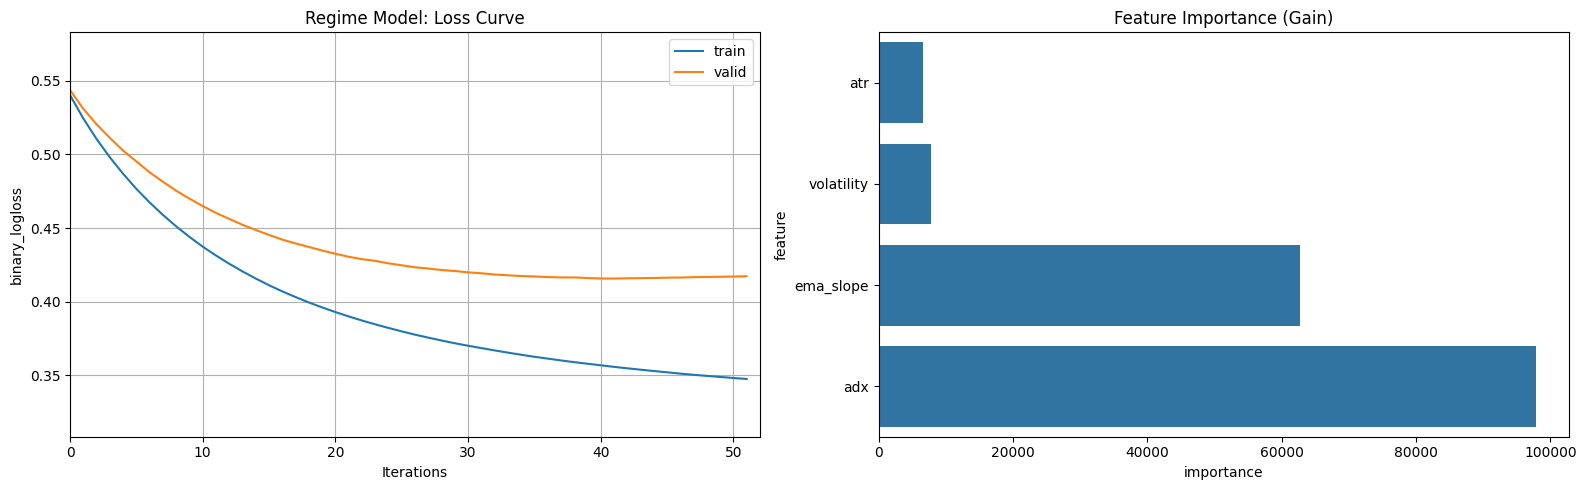


--- Отчет о классификации (Regime) ---
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      7925
           1       0.84      0.33      0.48      2587

    accuracy                           0.82     10512
   macro avg       0.83      0.66      0.68     10512
weighted avg       0.82      0.82      0.79     10512



In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

class RegimeModel:
    def __init__(self, n_estimators=100, learning_rate=0.05):
        self.model = lgb.LGBMClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            objective='binary',
            metric='binary_logloss',
            importance_type='gain',
            verbose=-1
        )
        self.feature_cols = ['adx', 'ema_slope', 'volatility', 'atr']

    def prepare_labels(self, df, window=24, threshold_mult=1.5):
        returns = df['close'].pct_change(window).abs()
        rolling_vol = returns.rolling(window=window*5).mean()
        labels = (returns > (rolling_vol * threshold_mult)).astype(int)
        return labels.fillna(0)

    def train(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X[self.feature_cols], y, test_size=0.2, shuffle=False)

        evals_result = {}
        self.model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            eval_names=['train', 'valid'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=10),
                lgb.record_evaluation(evals_result)
            ]
        )

        self._plot_training_results(evals_result, y_test, self.model.predict(X_test))
        return evals_result

    def _plot_training_results(self, evals_result, y_true, y_pred):
        fig, ax = plt.subplots(1, 2, figsize=(16, 5))

        # 1. Loss Curve
        lgb.plot_metric(evals_result, metric='binary_logloss', ax=ax[0])
        ax[0].set_title('Regime Model: Loss Curve')

        # 2. Importance
        importance = pd.DataFrame({'feature': self.feature_cols, 'importance': self.model.feature_importances_})
        sns.barplot(x='importance', y='feature', data=importance.sort_values('importance'), ax=ax[1])
        ax[1].set_title('Feature Importance (Gain)')

        plt.tight_layout()
        plt.show()

        print("\n--- Отчет о классификации (Regime) ---")
        print(classification_report(y_true, y_pred))

# --- Перезапуск обучения режима ---
if 'df_features' in globals():
    regime_engine = RegimeModel()
    y_labels = regime_engine.prepare_labels(df_features)
    regime_engine.train(df_features[regime_engine.feature_cols], y_labels)
    df_features['regime_pred'] = regime_engine.model.predict(df_features[regime_engine.feature_cols])

## 2. Модель волатильности

Назначение:
- Прогнозирование предстоящего сильного движения

Лучшие типы моделей:
- LightGBM
- Временная CNN
- LSTM (опционально)

Входные данные:
- ATR
- Реализованная волатильность
- Скачки объема
- Кластеризация волатильности

Выходные данные:
- Вероятность большого движения

Переобучение:
- Еженедельно

Новый баланс меток всплесков: 9450 из 52560
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[66]	valid_0's binary_logloss: 0.438916

--- Углубленный отчет по волатильности ---
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      8450
           1       0.55      0.24      0.33      2062

    accuracy                           0.81     10512
   macro avg       0.69      0.59      0.61     10512
weighted avg       0.78      0.81      0.78     10512



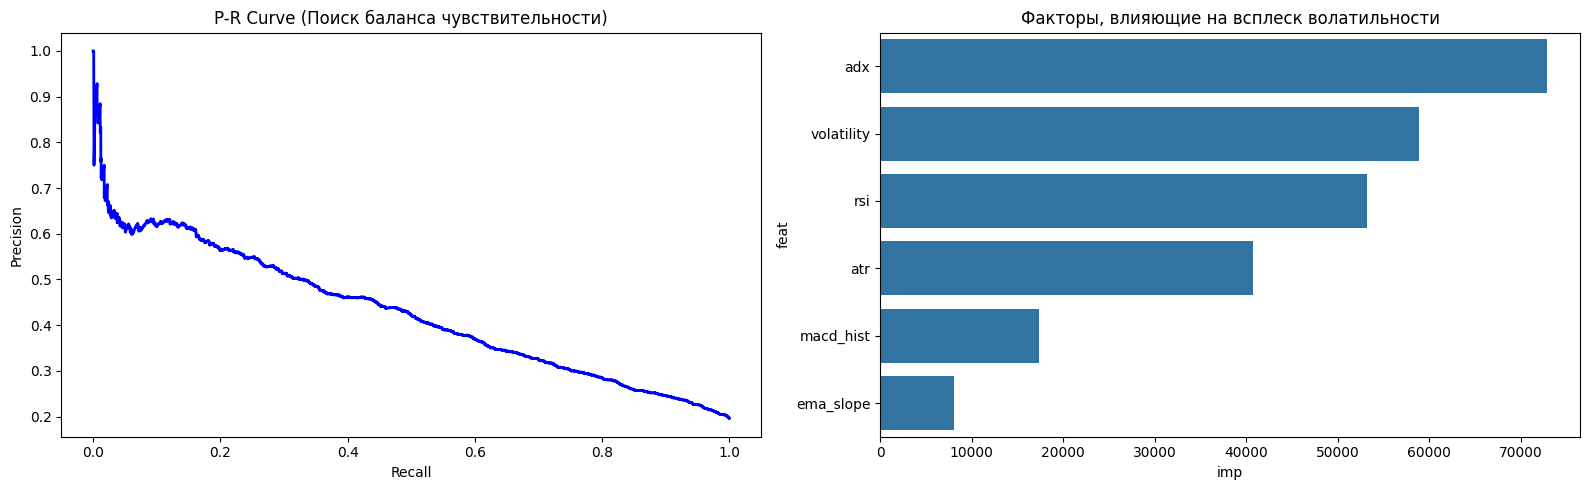

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

class VolatilityModel:
    def __init__(self, n_estimators=150, learning_rate=0.05):
        # Используем scale_pos_weight или is_unbalance для борьбы с редкими событиями
        self.model = lgb.LGBMClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            objective='binary',
            is_unbalance=True,
            importance_type='gain',
            verbose=-1
        )
        self.feature_cols = ['atr', 'volatility', 'adx', 'ema_slope', 'rsi', 'macd_hist']

    def prepare_labels(self, df, window=6, threshold_pct=0.5):
        """
        Создание меток: 1 если волатильность в ближайшие 'window' часов
        вырастет значительно выше текущего среднего.
        """
        # Берем максимальную волатильность в будущем окне
        future_max_vol = df['volatility'].shift(-window).rolling(window=window).max()
        current_avg_vol = df['volatility'].rolling(window=48).mean()

        labels = (future_max_vol > current_avg_vol * (1 + threshold_pct)).astype(int)
        return labels.fillna(0)

    def train(self, X, y):
        X_data = X[self.feature_cols]
        X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, shuffle=False)

        self.model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            callbacks=[lgb.early_stopping(stopping_rounds=20)]
        )

        # Получаем вероятности вместо жестких классов
        y_probs = self.model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs > 0.5).astype(int)

        print("\n--- Углубленный отчет по волатильности ---")
        print(classification_report(y_test, y_pred))

        self._plot_advanced_analytics(y_test, y_probs, X_data)

    def _plot_advanced_analytics(self, y_true, y_probs, X_data):
        fig, ax = plt.subplots(1, 2, figsize=(16, 5))

        # 1. Кривая Precision-Recall
        precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
        ax[0].plot(recall, precision, color='blue', lw=2)
        ax[0].set_xlabel('Recall')
        ax[0].set_ylabel('Precision')
        ax[0].set_title('P-R Curve (Поиск баланса чувствительности)')

        # 2. Важность признаков
        imp_df = pd.DataFrame({'feat': self.feature_cols, 'imp': self.model.feature_importances_})
        imp_df = imp_df.sort_values('imp', ascending=False)
        sns.barplot(x='imp', y='feat', data=imp_df, ax=ax[1])
        ax[1].set_title('Факторы, влияющие на всплеск волатильности')

        plt.tight_layout()
        plt.show()

# --- Запуск ---
if 'df_features' in globals():
    vol_module = VolatilityModel()
    y_vol_deep = vol_module.prepare_labels(df_features)

    print(f"Новый баланс меток всплесков: {y_vol_deep.sum()} из {len(y_vol_deep)}")

    vol_module.train(df_features, y_vol_deep)

    # Сохраняем вероятности (они полезнее для мета-фильтра)
    df_features['vol_spike_prob'] = vol_module.model.predict_proba(df_features[vol_module.feature_cols])[:, 1]
else:
    print("Ошибка: df_features не найден.")

## 3. Модель направления

Назначение:
- Прогнозирование продолжения направления

Лучшие типы моделей:
- LightGBM (лучшая отправная точка)
- Transformer (позже)
- Временная CNN

Входные данные:
- RSI
- Дельта MACD
- Импульс
- Расстояние прорыва
- Поток ордеров

Выходные данные:
- Вероятность лонга
- Вероятность шорта

Переобучение:
- Еженедельно

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[2]	train's binary_logloss: 0.691567	valid's binary_logloss: 0.692469


<Figure size 1000x400 with 0 Axes>

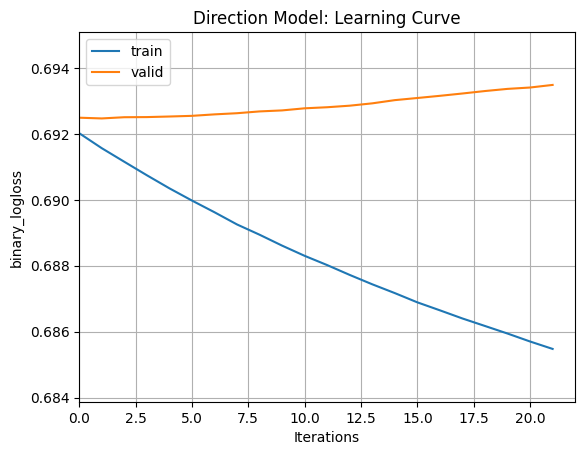

In [ ]:
class DirectionModel:
    def __init__(self, n_estimators=200, learning_rate=0.03):
        self.model = lgb.LGBMClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            objective='binary',
            metric='binary_logloss',
            importance_type='gain',
            verbose=-1
        )
        self.feature_cols = ['rsi', 'macd_hist', 'ema_slope', 'adx']

    def prepare_labels(self, df, horizon=12):
        future_close = df['close'].shift(-horizon)
        return (future_close > df['close']).astype(int).fillna(0)

    def train(self, X, y):
        X_data = X[self.feature_cols]
        X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, shuffle=False)

        evals_result = {}
        self.model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            eval_names=['train', 'valid'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=20),
                lgb.record_evaluation(evals_result)
            ]
        )

        plt.figure(figsize=(10, 4))
        lgb.plot_metric(evals_result, metric='binary_logloss')
        plt.title('Direction Model: Learning Curve')
        plt.show()

    def get_calibrated_signals(self, df, threshold=0.6):
        probs = self.model.predict_proba(df[self.feature_cols])[:, 1]
        signals = np.zeros(len(df))
        signals[probs > threshold] = 1
        signals[probs < (1 - threshold)] = -1
        return signals, probs

# --- Перезапуск обучения направления ---
if 'df_features' in globals():
    dir_model = DirectionModel()
    y_dir = dir_model.prepare_labels(df_features)
    dir_model.train(df_features, y_dir)

## 4. Модель мета-меток

Назначение:
- Принятие решения о принятии сигнала

Лучшие типы моделей:
- LightGBM
- Логистическая регрессия

Входные данные:
- Доверие модели
- Состояние режима
- Состояние волатильности
- Спред/проскальзывание

Выходные данные:
- Совершить сделку / пропустить сделку

Переобучение:
- Часто

In [ ]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score

class MetaFilterModel:
    def __init__(self, n_estimators=150):
        self.model = lgb.LGBMClassifier(
            n_estimators=n_estimators,
            learning_rate=0.03,
            objective='binary',
            is_unbalance=True,
            verbose=-1
        )
        # Мета-признаки: уверенность и состояние других моделей
        self.feature_cols = ['regime_pred', 'vol_spike_prob', 'direction_prob', 'adx', 'volatility']

    def prepare_meta_labels(self, df, horizon=12, fee=0.001, min_profit=0.005):
        """
        Создаем 'умную' метку: 1, если направление угадано правильно
        И доходность покрывает комиссии + минимальную целевую прибыль.
        """
        future_ret = df['close'].pct_change(horizon).shift(-horizon)

        # Определяем сторону на основе прогноза DirectionModel (вероятность > 0.5)
        side = np.where(df['direction_prob'] > 0.5, 1, -1)
        profit = side * future_ret

        # Теперь метка 1 ставится только если профит выше (комиссии + таргет)
        target_threshold = fee + min_profit
        labels = (profit > target_threshold).astype(int)

        print(f"\n--- Анализ меток мета-фильтра ---")
        print(f"Целевой порог доходности: {target_threshold*100:.2f}%")
        print(f"Распределение меток (1 = Качественная сделка):\n{labels.value_counts(normalize=True)}")

        return labels.fillna(0)

    def train(self, df):
        y = self.prepare_meta_labels(df)
        X = df[self.feature_cols]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        self.model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            callbacks=[lgb.early_stopping(stopping_rounds=15)]
        )

        y_pred = self.model.predict(X_test)
        print("\n--- Отчет Мета-фильтра (Поиск 'Жирных' сделок) ---")
        print(classification_report(y_test, y_pred))

        return self

# --- Запуск обновленной модели ---
if 'direction_prob' in df_features.columns:
    meta_model = MetaFilterModel()
    meta_model.train(df_features)

    # Обновляем решение мета-фильтра
    df_features['meta_decision'] = meta_model.model.predict(df_features[meta_model.feature_cols])

    # Генерируем финальный сигнал (используем направление только при одобрении мета-фильтром)
    # Примечание: здесь мы используем direction_prob > 0.5, но в идеале нужно
    # синхронизировать с direction_calibrated_signal из предыдущих шагов.
    df_features['final_signal'] = np.where(
        df_features['meta_decision'] == 1,
        np.where(df_features['direction_prob'] > 0.5, 1, -1),
        0
    )

    print(f"\nСгенерировано финальных сигналов после фильтрации: {df_features['final_signal'].abs().sum()}")
else:
    print("Ошибка: Необходимы прогнозы DirectionModel для обучения Мета-фильтра.")


--- Анализ меток мета-фильтра ---
Целевой порог доходности: 0.60%
Распределение меток (1 = Качественная сделка):
close
0    0.671195
1    0.328805
Name: proportion, dtype: float64
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 0.619019

--- Отчет Мета-фильтра (Поиск 'Жирных' сделок) ---
              precision    recall  f1-score   support

           0       0.69      1.00      0.82      7267
           1       0.00      0.00      0.00      3245

    accuracy                           0.69     10512
   macro avg       0.35      0.50      0.41     10512
weighted avg       0.48      0.69      0.57     10512


Сгенерировано финальных сигналов после фильтрации: 0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 5. Модель определения размера позиции

Назначение:
- Динамическое определение размера риска

Лучшие типы моделей:
- Регрессионная модель
- Байесовское определение размера
- Обучение с подкреплением (продвинутый уровень)

Входные данные:
- Доверие
- Волатильность
- Просадка
- Режим

Выходные данные:
- Размер позиции

Переобучение:
- Редко

In [ ]:
import numpy as np

class PositionSizer:
    def __init__(self, risk_per_trade=0.01, account_size=10000):
        """
        Динамический сайзинг на основе риска и волатильности.
        :param risk_per_trade: % капитала, которым мы рискуем в одной сделке (0.01 = 1%)
        """
        self.risk_per_trade = risk_per_trade
        self.account_size = account_size

    def calculate_sizes(self, df):
        """
        Расчет размера позиции на основе ATR (Average True Range).
        Размер = (Капитал * Риск) / (ATR * Множитель стопа)
        """
        # Множитель стопа (например, 2 * ATR)
        stop_multiplier = 2.0

        # Риск в валюте
        risk_amount = self.account_size * self.risk_per_trade

        # Размер позиции в базовом активе (BTC)
        # Избегаем деления на ноль, если ATR не рассчитан
        safe_atr = df['atr'].replace(0, np.nan)
        df['pos_size'] = risk_amount / (safe_atr * stop_multiplier)

        # Если сигнала нет, размер позиции 0
        df['final_pos_size'] = df['pos_size'] * df['final_signal'].abs()

        return df.fillna(0)

# --- Запуск ---
if 'final_signal' in df_features.columns:
    sizer = PositionSizer(risk_per_trade=0.01) # Рискуем 1% на сделку
    df_features = sizer.calculate_sizes(df_features)

    active_trades = df_features[df_features['final_signal'] != 0]
    print(f"--- Анализ размеров позиций ---")
    print(f"Средний размер позиции: {active_trades['final_pos_size'].mean():.4f} BTC")
    print(f"Макс размер: {active_trades['final_pos_size'].max():.4f} BTC")
    print(f"Мин размер: {active_trades['final_pos_size'].min():.4f} BTC")
else:
    print("Ошибка: Не найдены финальные сигналы для расчета позиций.")

--- Анализ размеров позиций ---
Средний размер позиции: 0.2619 BTC
Макс размер: 3.4728 BTC
Мин размер: 0.0220 BTC


# Дорожная карта развития проекта

## Фаза 1 (Базовая)
- Использование LightGBM
- Фильтры режима и волатильности
- Базовая мета-маркировка

## Фаза 2 (Расширенная)
- Интеграция Temporal CNN
- Multi-timeframe признаки
- Динамический сайзинг позиций

## Фаза 3 (Продвинутая)
- Архитектуры Transformer
- Обучение с подкреплением (RL)
- Оптимизация портфеля

In [ ]:
# Интеграция: Смягченное направление + Вероятностный Мета-фильтр
if 'df_features' in globals() and 'meta_model' in globals():
    print("--- Тонкая настройка финального сигнала (v2) ---")

    # 1. Смягчаем порог направления до 0.52
    SOFT_THRESHOLD = 0.52
    calibrated_signals_soft, _ = dir_model.get_calibrated_signals(df_features, threshold=SOFT_THRESHOLD)
    df_features['direction_soft_signal'] = calibrated_signals_soft

    # 2. Используем вероятности мета-фильтра
    meta_probs = meta_model.model.predict_proba(df_features[meta_model.feature_cols])[:, 1]
    df_features['meta_prob'] = meta_probs

    # 3. Берем только те сигналы, где мета-фильтр уверен выше среднего
    meta_threshold = df_features['meta_prob'].median()

    df_features['final_signal'] = np.where(
        (df_features['meta_prob'] > meta_threshold) & (df_features['direction_soft_signal'] != 0),
        df_features['direction_soft_signal'],
        0
    )

    active_signals = df_features['final_signal'].abs().sum()
    print(f"Порог направления: {SOFT_THRESHOLD}")
    print(f"Мета-порог (median): {meta_threshold:.4f}")
    print(f"Итоговых сигналов: {active_signals}")

    if active_signals > 0:
        sizer = PositionSizer(risk_per_trade=0.01)
        df_features = sizer.calculate_sizes(df_features)
else:
    print("Ошибка: Не найдены обученные модели для интеграции.")

--- Тонкая настройка финального сигнала (v2) ---
Порог направления: 0.52
Мета-порог (median): 0.3428
Итоговых сигналов: 9534.0


# Рекомендуемая структура Colab

01_load_data.ipynb
02_build_features.ipynb
03_build_labels.ipynb
04_train_regime.ipynb
05_train_volatility.ipynb
06_train_direction.ipynb
07_train_meta.ipynb
08_backtest.ipynb
09_analysis.ipynb

In [ ]:
# Заметки или код, связанные со структурой/рабочим процессом Colab

# Планы по дальнейшей реализации

**Приоритет 1 (Стабильность):**
- Улучшение фильтра волатильности
- Асимметричные пороги входа
- Глубокая калибровка вероятностей

**Приоритет 2 (Риск):**
- Оптимизация RL-агента для управления просадкой
- Анализ корреляции признаков

**Приоритет 3 (Масштабирование):**
- Переход к live-симуляции
- Тестирование на корзине активов

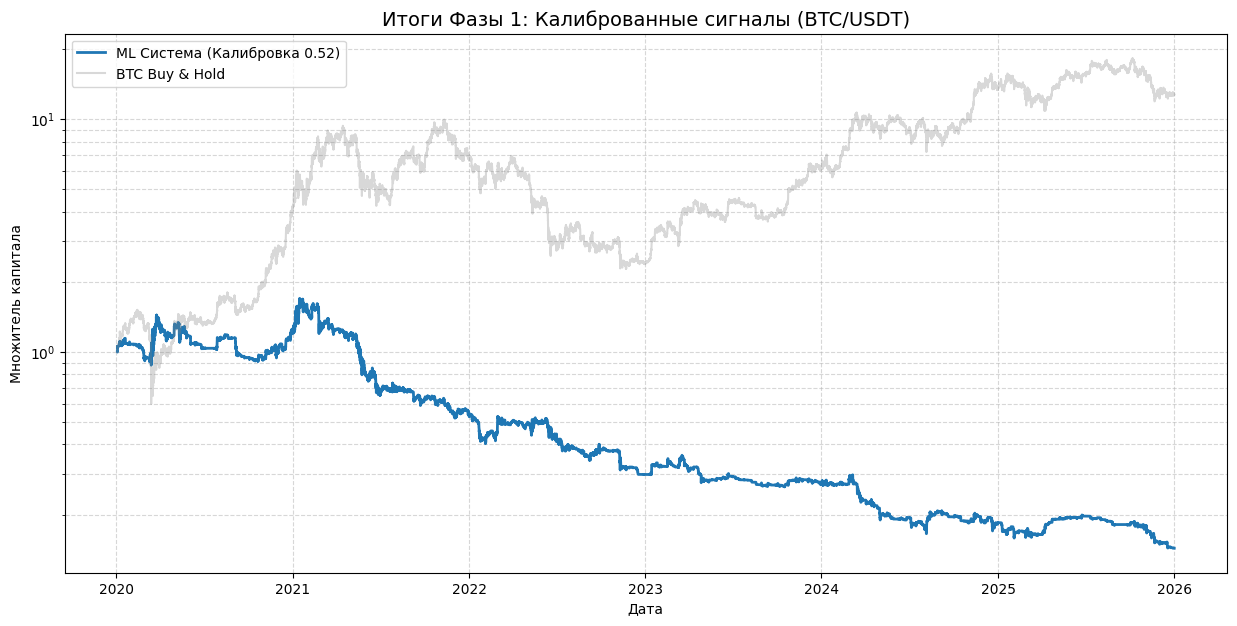


--- ИТОГОВЫЕ ПОКАЗАТЕЛИ (КАЛИБРОВКА 0.52) ---
Интервал: 2020-01-03 01:00:00 - 2026-01-01 00:00:00
--------------------------------------------------
Sharpe Ratio        -0.720236
Profit Factor        0.946719
Win Rate (%)        39.722043
Max Drawdown (%)   -91.567215
Recovery Factor     -0.935626
Total Return (%)   -85.672677
Эксперимент 'Full_History_Calibrated_v1' успешно сохранен в experiments_log.json


In [ ]:
import matplotlib.pyplot as plt

# --- Запуск итогового бэктеста на калиброванных сигналах ---
if 'df_features' in globals() and 'final_signal' in df_features.columns:
    # Инициализация бэктестера с реалистичными издержками
    bt = Backtester(commission=0.0006, slippage=0.0002)

    # Выполняем бэктест на откалиброванных сигналах
    perf_calibrated = bt.run(df_features, df_features['final_signal'])

    # Визуализация результатов
    plt.figure(figsize=(15, 7))
    plt.plot(perf_calibrated['cum_strategy_returns'], label='ML Система (Калибровка 0.52)', color='#1f77b4', lw=2)
    plt.plot(perf_calibrated['cum_market_returns'], label='BTC Buy & Hold', color='#7f7f7f', alpha=0.3)

    plt.title(f'Итоги Фазы 1: Калиброванные сигналы ({SYMBOL})', fontsize=14)
    plt.xlabel('Дата')
    plt.ylabel('Множитель капитала')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

    # Расчет метрик
    analyzer_calibrated = PerformanceMetrics(perf_calibrated)
    stats_calibrated = analyzer_calibrated.calculate_metrics()

    print(f"\n--- ИТОГОВЫЕ ПОКАЗАТЕЛИ (КАЛИБРОВКА 0.52) ---")
    print(f"Интервал: {df_features.index[0]} - {df_features.index[-1]}")
    print("-" * 50)
    print(stats_calibrated.to_string())

    # Логирование обновленного эксперимента
    logger.log_experiment('Full_History_Calibrated_v1', {
        'symbol': SYMBOL,
        'threshold': 0.52,
        'total_bars': len(df_features)
    }, stats_calibrated)
else:
    print("Ошибка: Не найдены сигналы для бэктеста.")